In [1]:
library(edgeR)
library(ggplot2)
library(ggrepel)
library(reshape2)
library(scales)
library(gridExtra)
library(TxDb.Hsapiens.UCSC.hg38.knownGene)
library(biomaRt)
library(patchwork)
library(ComplexHeatmap)
library(circlize)
library(ggrastr)
library(dplyr)
library(patchwork)
library(ChIPseeker)

Loading required package: limma

Loading required package: GenomicFeatures

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:gridExtra’:

    combine


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    Filter, Find, Map, Position, Reduce, anyDuplicated, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, setdiff, sort, table,
    tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    I, expan

## Plot ChromVAR

In [2]:
all_chromvar = read.csv("../data/210629_thp1_chromvar.csv")
dev_human_vals_mean = (all_chromvar[,(c(1:5)*2 - 1)] + all_chromvar[,(c(1:5)*2)])/2
colnames(dev_human_vals_mean) = c("DMSO", "BRQ 24h", "BRQ 48h", "PMA 24", "PMA 48h")
head(dev_human_vals_mean)

,DMSO,BRQ 24h,BRQ 48h,PMA 24,PMA 48h
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SMARCC1,-0.1725690,-0.04034154,0.06261543,0.09523380,0.03305613
JUNB,-0.1827696,-0.04514217,0.06470005,0.10193946,0.03794427
FOSL1,-0.1783796,-0.04144049,0.06379887,0.09805670,0.03538317
FOSL2,-0.1845922,-0.04462414,0.06448878,0.10223978,0.03933368
FOS,-0.1741598,-0.03883304,0.06538234,0.09183981,0.03395977
JUND,-0.1703025,-0.03701775,0.06256689,0.09122357,0.03230963


Warning message:
“The input is a data frame, convert it to a matrix.”


pdf 
  2

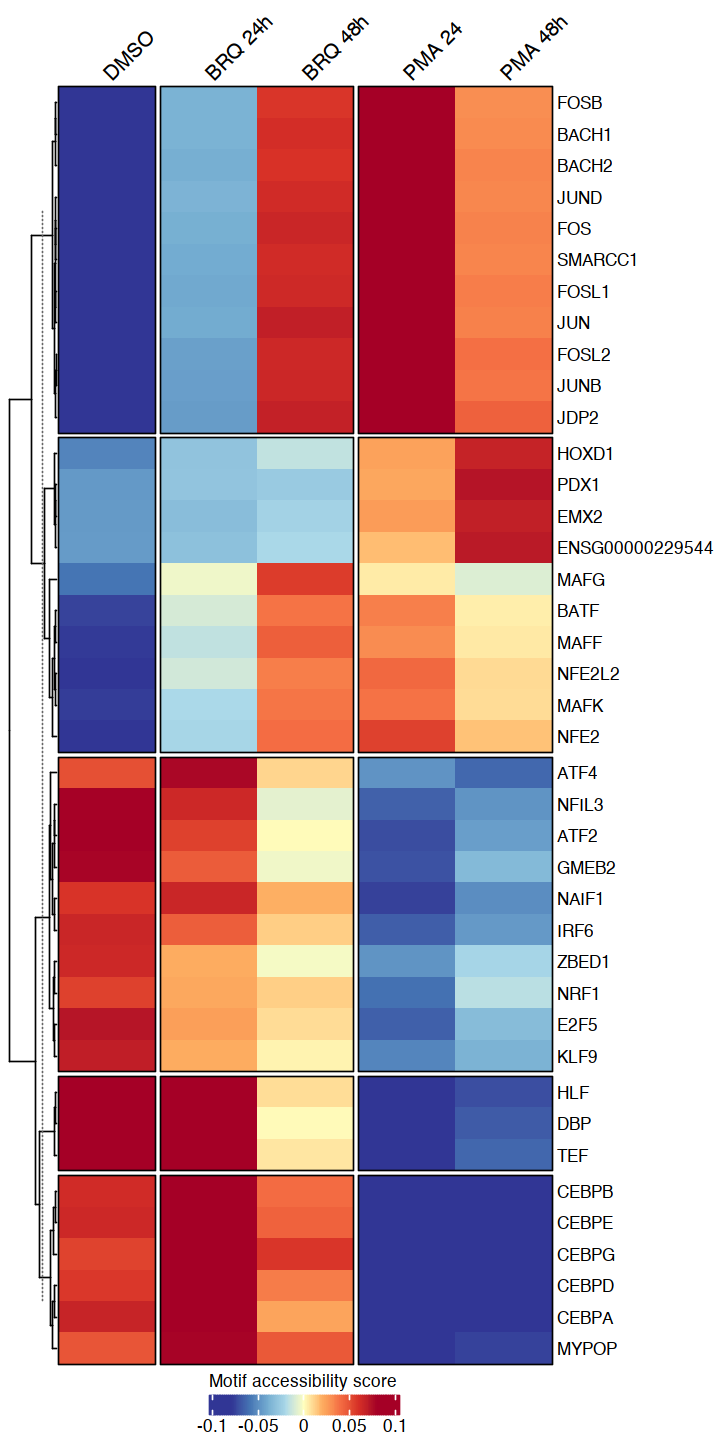

In [7]:
# Top 40 motifs

chromvar_range = apply(dev_human_vals_mean, 1, function(x) abs(range(x)[2] - range(x)[1]))
hirange = names(chromvar_range[order(-chromvar_range)][1:40])

options(repr.plot.width=6, repr.plot.height=12)
h = Heatmap(dev_human_vals_mean[hirange,], 
        cluster_columns = F, 
        cluster_rows = T,
        row_km=5,
        row_km_repeats=100,
        column_names_side = "top", 
        column_names_rot = 45,
        column_split=c(1,2,2,3,3),
        column_title=NULL,
        row_title=NULL,
        border=T,
        row_title_rot=0,
        row_names_gp = gpar(fontsize = 10),
        col = colorRamp2(seq(-0.08, 0.08, length.out = 9), 
                         rev(RColorBrewer::brewer.pal(name = "RdYlBu", n = 11))[c(1:4, 6, 8:11)]),
       heatmap_legend_param = list(
                title="Motif accessibility score",
                direction="horizontal"))

draw(h, heatmap_legend_side="bottom")

pdf("../output/220510_thp1_top30_atac.pdf", width=4, height=6)
draw(h, heatmap_legend_side="bottom")
dev.off()

Warning message:
“The input is a data frame, convert it to a matrix.”


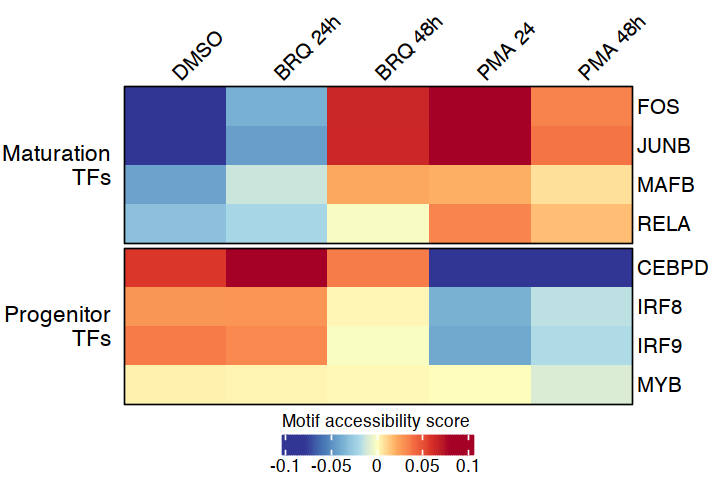

In [176]:
# Selected motifs only

motifs_of_interest = c("FOS", "JUNB", "MAFB", "RELA", "CEBPD", "IRF8", "IRF9", "MYB")

options(repr.plot.width=6, repr.plot.height=4)
h = Heatmap(dev_human_vals_mean[motifs_of_interest,], 
        cluster_columns = F, 
        cluster_rows = F,
        column_names_side = "top", 
        column_names_rot = 45,
        border=T,
        row_split = c(rep("Maturation\nTFs", 4), rep("Progenitor\nTFs", 4)),
        row_title_rot=0,
        col = colorRamp2(seq(-0.08, 0.08, length.out = 9), 
                         rev(RColorBrewer::brewer.pal(name = "RdYlBu", n = 11))[c(1:4, 6, 8:11)]),
       heatmap_legend_param = list(
                                   title="Motif accessibility score",
                                   direction="horizontal"))

draw(h, heatmap_legend_side="bottom")

# pdf("../output/220426_thp1_selected_atac.pdf", width=4, height=3)
# draw(h, heatmap_legend_side="bottom")
# dev.off()


## Use ATACseq peaks as features for chromatin mods
Because the vast majority of binding events and active epigenetic marks occur at open chromatin, we calculate a master list of ATAC peaks across all the conditions

In [20]:
# extending summits by 25bp to allow intersection of similar summits
parallel -j 8 --dryrun "awk 'BEGIN {OFS=\"\t\"}; {print(\$1,\$2-25,\$3+25,\$4,\$5)}' {} > {.}_pm25.bed" ::: *_summits.bed

# get only peaks that are in both replicates for each timepoint, and take the peak from the first replicate
# peaks must overlap by at least half  
parallel -j 8 "bedtools intersect -a THP1_{}_rep1_ATACseq_peaks.narrowPeak \
-b THP1_{}_rep2_ATACseq_peaks.narrowPeak -f 0.5 -r -wa > THP1_{}_peaks_comb.bed" ::: DMSO BRQ24 BRQ48 PMA24  PMA48

# make a single file of all peaks, disallowing 50bp overlap
cat THP1*_peaks_comb.bed | sort -k1,1 -k2,2n | bedtools merge -i - -d 50 > ../../intermediate_files/THP1_all_peaks.bed
awk 'BEGIN {{OFS="\t"; print("GeneID", "Chr", "Start", "End", "Strand")}}; \
      {{print("peak" NR,$1,$2,$3,"+")}}' ../../intermediate_files/THP1_all_peaks.bed > \
      ../../intermediate_files/THP1_all_peaks.saf

# create a featureCounts including BD302 CUT&RUN for H3K27ac -- so we can do differential analysis to more stringently identify K27ac-up peaks 
# using ATAC peaks as main master list
# will also include MLL1/3 
featureCounts -T 10 -p -O -M --fraction -F SAF -a \
../../atacseq_analysis/intermediate_files/THP1_all_peaks.saf \
-o 220612_thp1_atac_k27ac_pu1_mll_at_atac.txt \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/THP1_DMSO_rep1_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/THP1_DMSO_rep2_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/THP1_BRQ24_rep1_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/THP1_BRQ24_rep2_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/THP1_BRQ48_rep1_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/THP1_BRQ48_rep2_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/THP1_PMA24_rep1_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/THP1_PMA24_rep2_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/THP1_PMA48_rep1_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/atacseq_analysis/results/bowtie2_bam/THP1_PMA48_rep2_ATACseq_aligned_reads_sorted_nodup_noblacklist_noM.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/cutandrun_analysis/results/bowtie2_bam/THP_DMSO_H3K27ac_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/cutandrun_analysis/results/bowtie2_bam/THP_BRQ_24h_H3K27ac_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/cutandrun_analysis/results/bowtie2_bam/THP_BRQ_48h_H3K27ac_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/cutandrun_analysis/results/bowtie2_bam/THP_PMA_24h_H3K27ac_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/cutandrun_analysis/results/bowtie2_bam/THP_PMA_48h_H3K27ac_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/220211VanA/hg38/results/bowtie2_bam/THP-1_H3K27ac_DMSO_24h_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/220211VanA/hg38/results/bowtie2_bam/THP-1_H3K27ac_HU1mM_4h_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/220211VanA/hg38/results/bowtie2_bam/THP-1_H3K27ac_BRQ500nM_4h_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/220211VanA/hg38/results/bowtie2_bam/THP-1_H3K27ac_PMA100nM_4h_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/220211VanA/hg38/results/bowtie2_bam/THP-1_H3K27ac_BRQ500nM_24h_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/220211VanA/hg38/results/bowtie2_bam/THP-1_H3K27ac_PMA100nM_24h_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/cutandrun_analysis/results/bowtie2_bam/THP_DMSO_PU1_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/cutandrun_analysis/results/bowtie2_bam/THP_BRQ_24h_PU1_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/cutandrun_analysis/results/bowtie2_bam/THP_BRQ_48h_PU1_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/cutandrun_analysis/results/bowtie2_bam/THP_PMA_24h_PU1_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/differentiation_manuscript/cutandrun_analysis/results/bowtie2_bam/THP_PMA_48h_PU1_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/220211VanA/hg38/results/bowtie2_bam/THP-1_MLL1c_DMSO_24h_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/220211VanA/hg38/results/bowtie2_bam/THP-1_MLL1c_BRQ500nM_24h_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/220211VanA/hg38/results/bowtie2_bam/THP-1_MLL1c_PMA100nM_24h_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/220211VanA/hg38/results/bowtie2_bam/THP-1_MLL3_DMSO_24h_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/220211VanA/hg38/results/bowtie2_bam/THP-1_MLL3_BRQ500nM_24h_aligned_sorted_rmdup_noblacklist.bam \
/net/rowley/ifs/data/vanderheiden/briando/files/220211VanA/hg38/results/bowtie2_bam/THP-1_MLL3_PMA100nM_24h_aligned_sorted_rmdup_noblacklist.bam


ERROR: Error in parse(text = x, srcfile = src): <text>:2:13: unexpected numeric constant
1: # extending summits by 25bp to allow intersection of similar summits
2: parallel -j 8
               ^


## Read in count file and get differential peaks

In [8]:
setwd("~/Dropbox (MIT)/MVH_Code/brq/code")
df = read.table("../output/220612_thp1_atac_k27ac_pu1_mll_at_atac.txt", header = TRUE, row.names=1)
peak_info = df[,1:5]
df = df[,6:dim(df)[2]]
colnames(df) = c("dmso_r1", "dmso_r2", "b24_r1", "b24_r2", "b48_r1", "b48_r2", "p24_r1", "p24_r2",
"p48_r1", "p48_r2", "d_k27ac", "b24_k27ac", "b48_k27ac", "p24_k27ac", "p48_k27ac",
"d_k27ac_new", "h4_k27ac_new", "b4_k27ac_new", "p4_k27ac_new", "b24_k27ac_new", "p24_k27ac_new",
"d_pu1", "b24_pu1", "b48_pu1", "p24_pu1", "p48_pu1",
"d_mll1", "b24_mll1", "p24_mll1", "d_mll3", "b24_mll3", "p24_mll3")
head(df)

,dmso_r1,dmso_r2,b24_r1,b24_r2,b48_r1,b48_r2,p24_r1,p24_r2,p48_r1,p48_r2,⋯,b24_pu1,b48_pu1,p24_pu1,p48_pu1,d_mll1,b24_mll1,p24_mll1,d_mll3,b24_mll3,p24_mll3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
peak1,3,7,21.5,3,61.5,56.5,33,32,114.5,69,⋯,9.5,31,34,33.5,2.5,2,5.5,6.5,5,3.5
peak2,4,24,24.5,13,42.5,37.5,49,28,122.5,79,⋯,46.5,49,79,93.5,17.5,11,25.5,8.5,7,3.5
peak3,0,0,4.0,3,58.0,73.0,12,8,18.0,15,⋯,12.0,54,34,41.0,0.0,10,5.0,5.0,5,5.0
peak4,38,135,224.0,104,307.0,327.0,229,175,328.0,204,⋯,139.0,137,196,146.0,38.0,88,76.0,9.0,14,8.0
peak5,99,265,153.0,74,190.0,207.0,142,116,204.0,146,⋯,54.0,42,80,68.0,77.0,105,86.0,18.0,14,3.0
peak6,6,21,7.0,6,3.0,6.0,5,7,19.0,10,⋯,7.0,1,5,6.0,7.0,2,2.0,2.0,1,2.0


In [3]:
# peak_info_bed = peak_info[,1:3]
# peak_info_bed$peak_name = row.names(peak_info)
# write.table(peak_info_bed, "../output/220527_thp1_all_peak_info.bed", sep='\t', row.names=F, col.names=F, quote=F)

In [9]:
# differential peaks
d0 <- DGEList(df[,1:10])
d0 <- calcNormFactors(d0, method="TMM")
cutoff <- 3
drop <- which(apply(cpm(d0), 1, max) < cutoff)
d <- d0[-drop,] 
dim(d) # number of genes left

[1] 110278     10

In [10]:
# conditions for differential peak calling
conds = as.character(sapply(names(df[,1:10]), function(x) strsplit(x,'_')[[1]][1]))
conds

[1] "dmso" "dmso" "b24"  "b24"  "b48"  "b48"  "p24"  "p24"  "p48"  "p48"

,condsb24,condsb48,condsdmso,condsp24,condsp48
peak1,0.6127177,2.178461,-0.5822365,1.8688074,3.1876857
peak2,1.2932162,1.619352,0.8089739,2.0942259,3.3261755
peak3,-0.9991452,2.333523,-3.8132057,0.2196193,0.7430784
peak4,4.4130464,4.602165,3.4024709,4.4902338,4.7184271
peak5,3.8840671,3.928339,4.4963020,3.8474649,4.1242613
peak7,2.1521603,1.933962,1.8950263,1.2823676,1.7065681


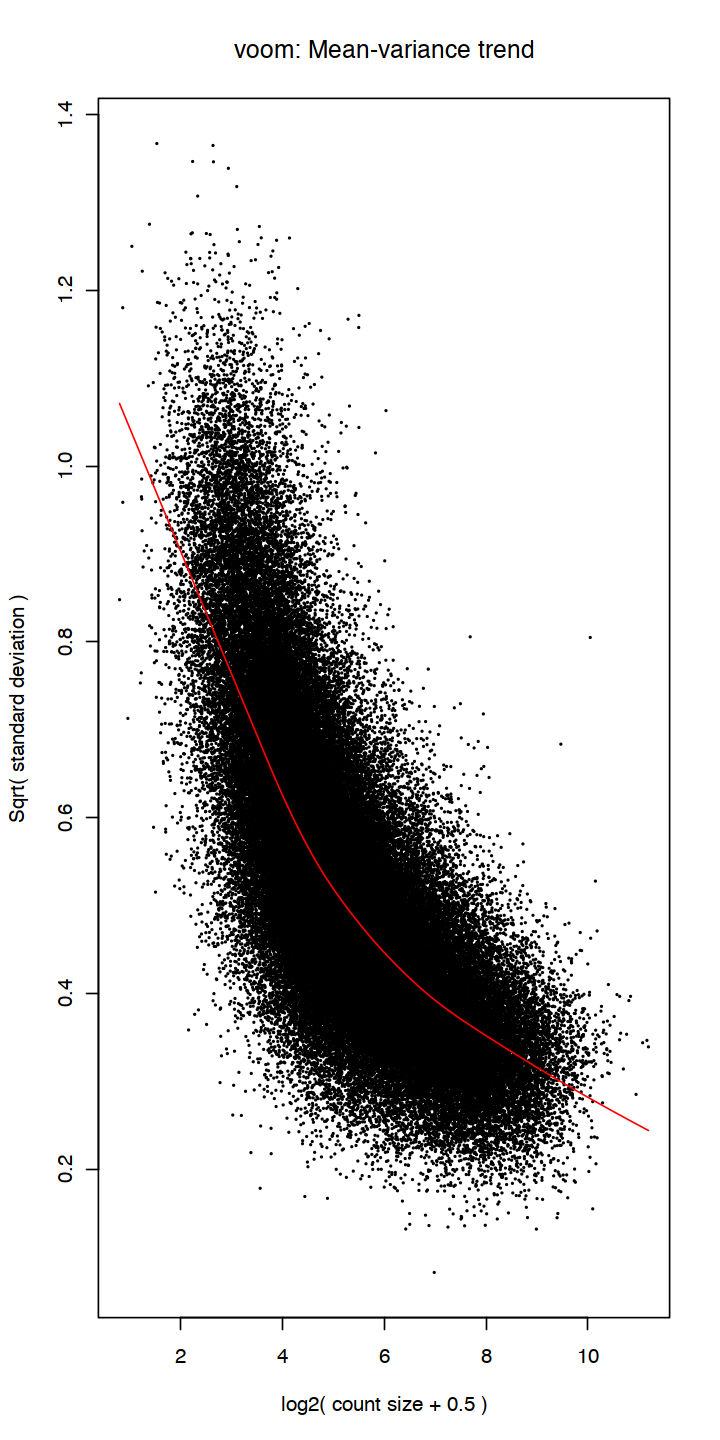

In [11]:
# normalize
mm <- model.matrix(~0 + conds)
y <- voom(d, mm, plot = T)
fit <- lmFit(y, mm)
head(coef(fit))

In [12]:
# get differentially accessible peaks for each condition
process_res = function(res) {
    tmp <- contrasts.fit(fit, res)
    tmp <- eBayes(tmp)
    res <- topTable(tmp, sort.by = "P", n = Inf)
    return(res)
}

p24_dep = process_res(makeContrasts("condsp24 - condsdmso", levels = colnames(coef(fit))))
p48_dep = process_res(makeContrasts("condsp48 - condsdmso", levels = colnames(coef(fit))))
p_dep = list(p24_dep, p48_dep)

b24_dep = process_res(makeContrasts("condsb24 - condsdmso", levels = colnames(coef(fit))))
b48_dep = process_res(makeContrasts("condsb48 - condsdmso", levels = colnames(coef(fit))))
b_dep = list(b24_dep, b48_dep)


In [13]:
# get BRQ up and down
brq_chg = list()
pma_chg = list()
shared_chg = list()

for (tp in 1:2) {
    res = b_dep[[tp]]
    up = rownames(res[res$logFC > 1.5 & res$adj.P.Val < 0.05,])
    down = rownames(res[res$logFC < -1.5 & res$adj.P.Val < 0.05,])
    brq_chg[[tp]] = c(length(up), length(down))

    res2 = p_dep[[tp]]
    up2 = rownames(res2[res2$logFC > 1.5 & res2$adj.P.Val < 0.05,])
    down2 = rownames(res2[res2$logFC < -1.5 & res2$adj.P.Val < 0.05,])
    pma_chg[[tp]] = c(length(up2), length(down2))
    
    shared_chg[[tp]] = c(length(intersect(up, up2)), length(intersect(down, down2)))
}

In [14]:
# get number of diff peaks
nums = c(c(0,0), unlist(brq_chg), c(0,0), unlist(pma_chg), c(0,0), unlist(shared_chg))
tp = rep(c(0, 0, 24, 24, 48, 48), 3)
tx = c(rep("BRQ", 6), rep("PMA", 6), rep("Shared", 6))
dir = rep(c("up", "down"), 9)
df_chg = as.data.frame(cbind(nums, tp, tx, dir))
df_chg$nums = as.numeric(df_chg$nums)
df_chg[df_chg$dir == "down", ]$nums = -1 * df_chg[df_chg$dir == "down", ]$nums
df_chg$tx = factor(df_chg$tx, levels=c("Shared", "BRQ", "PMA"))
df_chg

nums,tp,tx,dir
<dbl>,<chr>,<fct>,<chr>
0,0,BRQ,up
0,0,BRQ,down
5631,24,BRQ,up
-962,24,BRQ,down
15503,48,BRQ,up
-7096,48,BRQ,down
0,0,PMA,up
0,0,PMA,down
22662,24,PMA,up


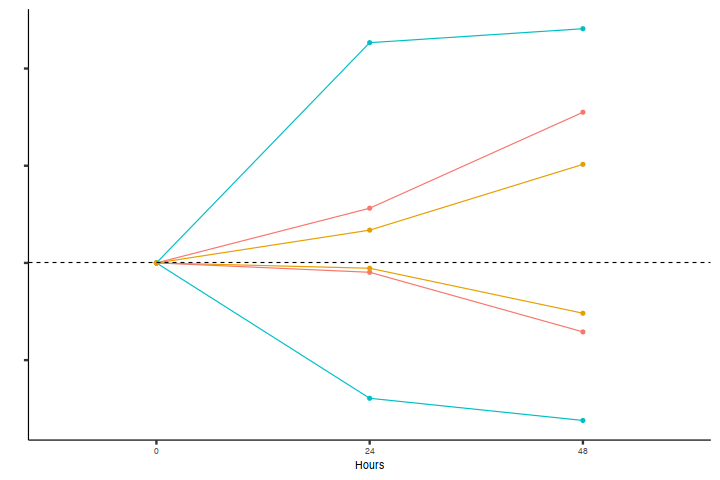

In [185]:
# Changes in peak # over time

ggplot(data=df_chg, aes(x=tp, y=nums, color=tx, group=interaction(tx, dir))) + 
geom_line(size=0.25) + geom_point(size=0.4) + theme_bw() + 
geom_hline(yintercept=c(0),linetype="dashed", size=0.25) +
scale_color_manual(values=c("#E69F00", "#F8766D", "#00BFC4")) +
labs(x="Hours") + labs(y="") + 
theme(panel.border = element_blank(), 
      legend.position = "none",
      panel.grid.minor = element_blank(),
      panel.grid.major = element_blank(),
      axis.line = element_line(colour = "black", size=0.25),
      text = element_text(size = 6),
      axis.text.y=element_blank(),  # -2000, 0, and 2000
      plot.title = element_text(size=8))

# ggsave("../output/220426_thp1_changed_peaks.pdf", width=1.33, height=1.33)


In [21]:
# get rnaseq LFCs
# these are TPMs
rnaseq = read.table("../data/220226_thp1_bd153_bd262_combined_rnaseq.txt")
print(names(rnaseq))
head(rnaseq)
dmso_avg = with(rnaseq, (dmso48_r1 + dmso48_r2 + dmso48_r3 + dmso48_r4)/4)
rnaseq$b24_rna_lfc = with(rnaseq, (brq24_r1 + brq24_r2 + brq24_r4)/3  - dmso_avg)
rnaseq$b48_rna_lfc = with(rnaseq, (brq48_r1 + brq48_r2 + brq48_r3 + brq48_r4)/4  - dmso_avg)
rnaseq$p24_rna_lfc = with(rnaseq, (pma24_r1 + pma24_r2 + pma24_r3 + pma24_r4)/4  - dmso_avg)
rnaseq$p48_rna_lfc = with(rnaseq, (pma48_r1 + pma48_r2 + pma48_r3 + pma48_r4)/4  - dmso_avg)

rnaseq_lfc = rnaseq[,(dim(rnaseq)[2]-3):dim(rnaseq)[2]]

dim(rnaseq_lfc)
head(rnaseq_lfc)


 [1] "dmso48_r1"     "dmso48_r2"     "dmso48_r3"     "dmso48_r4"    
 [5] "brq24_r1"      "brq24_r2"      "brq24_r4"      "brq48_r1"     
 [9] "brq48_r2"      "brq48_r3"      "brq48_r4"      "THP1_BRQ_4d"  
[13] "THP1_BRQ_4d.1" "THP1_BRQ_4d.2" "THP1_HU_2d"    "THP1_HU_2d.1" 
[17] "THP1_HU_2d.2"  "THP1_HU_2d.3"  "THP1_HU_4d"    "THP1_HU_4d.1" 
[21] "THP1_HU_4d.2"  "pma24_r1"      "pma24_r2"      "pma24_r3"     
[25] "pma24_r4"      "pma48_r1"      "pma48_r2"      "pma48_r3"     
[29] "pma48_r4"     


,dmso48_r1,dmso48_r2,dmso48_r3,dmso48_r4,brq24_r1,brq24_r2,brq24_r4,brq48_r1,brq48_r2,brq48_r3,⋯,THP1_HU_4d.1,THP1_HU_4d.2,pma24_r1,pma24_r2,pma24_r3,pma24_r4,pma48_r1,pma48_r2,pma48_r3,pma48_r4
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MTND1P23,9.042437,8.585824,8.518320,8.690949,8.868618,8.823341,8.847620,8.490432,8.418245,8.452007,⋯,0.967927,0.0000000,10.123715,10.094584,10.311137,10.290591,9.651240,9.509997,9.388262,9.440034
MTND2P28,6.800823,7.039920,6.888929,6.866804,7.058128,6.648363,7.169885,7.197796,7.144986,7.289967,⋯,1.951619,0.0000000,7.865164,7.301895,8.118313,8.185947,7.363913,7.475739,7.405199,7.516018
hsa-mir-6723,10.523703,10.728332,10.713265,11.051064,11.882729,11.714044,12.153000,11.996808,11.754391,12.455196,⋯,7.895393,7.7597293,13.155543,11.993666,13.183254,13.442242,13.147437,13.104481,13.114676,13.282008
MTATP6P1,9.794509,9.762779,9.745393,9.831907,9.566218,9.678048,9.832094,9.834886,9.762362,9.836308,⋯,1.951619,0.9668294,10.973038,10.948914,10.994503,11.109349,10.508873,10.552717,10.533164,10.529996
RP5-857K21.11,10.138208,10.169439,10.132874,10.182746,9.684004,9.510632,9.706434,9.427976,9.401160,9.050690,⋯,6.427715,6.0631424,11.191165,11.208615,11.185036,11.265073,10.452746,10.492669,10.334366,10.321577
LINC01128,1.283547,1.993165,2.401019,2.784417,2.374676,3.114131,1.105592,2.859133,2.451499,2.047473,⋯,2.751928,0.0000000,1.901418,2.552105,3.776740,2.759682,3.827342,3.121832,3.491201,3.222894


[1] 10508     4

,b24_rna_lfc,b48_rna_lfc,p24_rna_lfc,p48_rna_lfc
,<dbl>,<dbl>,<dbl>,<dbl>
MTND1P23,0.13714421,-0.19124589,1.4956246,0.7880011
MTND2P28,0.05967291,0.33640937,0.9687104,0.5410979
hsa-mir-6723,1.16250005,1.30116979,2.1895855,2.4080597
MTATP6P1,-0.09152717,0.06577179,1.2228036,0.7475405
RP5-857K21.11,-0.52212694,-0.83303466,1.0566556,0.2445231
LINC01128,0.08259590,0.44496938,0.6319493,1.3002802


In [20]:
names(rnaseq)

[1] "dmso48_r1"     "dmso48_r2"     "dmso48_r3"     "dmso48_r4"    
 [5] "brq24_r1"      "brq24_r2"      "brq24_r4"      "brq48_r1"     
 [9] "brq48_r2"      "brq48_r3"      "brq48_r4"      "THP1_BRQ_4d"  
[13] "THP1_BRQ_4d.1" "THP1_BRQ_4d.2" "THP1_HU_2d"    "THP1_HU_2d.1" 
[17] "THP1_HU_2d.2"  "THP1_HU_2d.3"  "THP1_HU_4d"    "THP1_HU_4d.1" 
[21] "THP1_HU_4d.2"  "pma24_r1"      "pma24_r2"      "pma24_r3"     
[25] "pma24_r4"      "pma48_r1"      "pma48_r2"      "pma48_r3"     
[29] "pma48_r4"      "b24_rna_lfc"   "b48_rna_lfc"   "p24_rna_lfc"  
[33] "p48_rna_lfc"

In [25]:
# ATAC peaks near genes that are uniquely up in PMA
z = subset(rnaseq_lfc, b48_rna_lfc > 1 & p48_rna_lfc > 1)
z[order(-z$p48_rna_lfc),]

,b24_rna_lfc,b48_rna_lfc,p24_rna_lfc,p48_rna_lfc
,<dbl>,<dbl>,<dbl>,<dbl>
AIM2,2.98912915,4.564968,7.034901,8.589847
MYOZ2,0.26872340,4.903103,5.667259,8.560717
FABP4,0.83117786,3.650283,5.633327,8.550255
CCL20,1.31661247,2.723480,5.586594,8.323636
PINLYP,-0.30204657,2.443923,5.424088,8.101504
RIN2,2.78670185,5.570552,7.804081,8.060338
CLEC2B,2.09787021,6.609236,6.840900,8.024119
MAP3K7CL,-0.22741235,3.313388,6.545000,7.938658
DAB2,0.68604212,3.748185,6.853817,7.786172


In [28]:
# ATAC peaks near genes that are uniquely up in BRQ 
z = subset(rnaseq_lfc, b24_rna_lfc > 1 & p24_rna_lfc < 0 & p48_rna_lfc < 0)
z[order(-z$b48_rna_lfc),][1:100,]

,b24_rna_lfc,b48_rna_lfc,p24_rna_lfc,p48_rna_lfc
,<dbl>,<dbl>,<dbl>,<dbl>
LILRA6,2.027131,5.926972,-0.17253444,-0.002634082
FAM65B,1.015426,5.116441,-1.81456419,-0.445781458
RP3-333A15.1,2.226113,4.829572,-1.93635505,-1.554455464
CTD-2006K23.1,2.200970,4.653846,-0.14477661,-0.159117652
TNFAIP6,3.802394,4.630061,-0.41588784,-2.098840010
TGM5,4.771609,4.184186,-1.82954361,-2.028126049
VCAN,2.348487,4.088361,-2.68888009,-3.434657065
LYPD6B,2.442697,4.051182,-1.51773988,-1.135840301
LINC00211,3.220433,4.036126,-2.42125374,-2.435594779


In [16]:
# processing region-gene associations from GREAT
great_data = read.table("../data/20220226-public-4.0.4-WIViwg-hg38-all-region.txt", sep='\t')
great_data = great_data[great_data$V2 != "NONE",]
great_data$gene = sapply(great_data$V2, function(x) strsplit(x, split = ' ')[[1]][1])
great_data$dist = sapply(great_data$V2, function(x) strsplit(x, split = ' ')[[1]][2])
great_data$dist = as.numeric(gsub('(', '', gsub(')', '', great_data$dist, fixed=T), fixed=T))
rownames(great_data) = great_data$V1
colnames(great_data) = c("peak_id", "great_output", "gene", "dist")
head(great_data)

,peak_id,great_output,gene,dist
,<chr>,<chr>,<chr>,<dbl>
peak10,peak10,SAMD11 (-48887),SAMD11,-48887
peak11,peak11,SAMD11 (-34756),SAMD11,-34756
peak12,peak12,SAMD11 (-21736),SAMD11,-21736
peak13,peak13,SAMD11 (-21146),SAMD11,-21146
peak14,peak14,SAMD11 (-14389),SAMD11,-14389
peak15,peak15,SAMD11 (-12725),SAMD11,-12725


In [17]:
tail(great_data)

,peak_id,great_output,gene,dist
,<chr>,<chr>,<chr>,<dbl>
peak173587,peak173587,VAMP7 (+6982),VAMP7,6982
peak173588,peak173588,VAMP7 (+10234),VAMP7,10234
peak173589,peak173589,VAMP7 (+12373),VAMP7,12373
peak173590,peak173590,VAMP7 (+17981),VAMP7,17981
peak173591,peak173591,IL9R (-30504),IL9R,-30504
peak173592,peak173592,IL9R (-25705),IL9R,-25705


### Normalize by library size

In [15]:
df_summ = read.table("../output/220612_thp1_atac_k27ac_pu1_mll_at_atac.txt.summary", header=T, row.names=1)
df_librarysize = apply(df_summ,2,sum)

# normalize by library size, multiply by 1 million
df_norm_lb = sweep(df, 2, df_librarysize, `/`) * 1e6

# normalize by bp of peak size, multiply by 1000
df_norm = sweep(df_norm_lb, 1, peak_info$Length, `/`) * 1e3
head(df_norm)

,dmso_r1,dmso_r2,b24_r1,b24_r2,b48_r1,b48_r2,p24_r1,p24_r2,p48_r1,p48_r2,⋯,b24_pu1,b48_pu1,p24_pu1,p48_pu1,d_mll1,b24_mll1,p24_mll1,d_mll3,b24_mll3,p24_mll3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
peak1,0.5774096,0.4411291,1.5896134,0.5368706,5.4839398,4.2936656,3.934790,4.444859,11.259148,9.768722,⋯,0.7672000,2.633625,2.9648304,2.7940909,0.3325784,0.2310456,0.7315389,0.5397135,0.4564515,0.4822153
peak2,0.6482574,1.2735138,1.5252600,1.9589191,3.1910326,2.3995831,4.919585,3.274845,10.142870,9.417606,⋯,3.1620061,3.505202,5.8005982,6.5664718,1.9602744,1.0700036,2.8558782,0.5942834,0.5380808,0.4060371
peak3,0.0000000,0.0000000,0.4352879,0.7901930,7.6121803,8.1651871,2.105971,1.635541,2.605170,3.125672,⋯,1.4263620,6.752265,4.3637853,5.0331873,0.0000000,1.7003225,0.9788322,0.6110594,0.6718281,1.0139264
peak4,5.1544369,5.9956504,11.6717495,13.1164595,19.2926028,17.5130751,19.243232,17.130930,22.730488,20.354185,⋯,7.9110601,8.202527,12.0451413,8.5819003,3.5626451,7.1644911,7.1239889,0.5266563,0.9007154,0.7767795
peak5,8.6884798,7.6148154,5.1581069,6.0384570,7.7253296,7.1729198,7.720437,7.347031,9.146945,9.425131,⋯,1.9884955,1.626999,3.1809496,2.5861308,4.6707934,5.5309909,5.2157776,0.6815038,0.5827719,0.1884690
peak6,1.9750646,2.2633632,0.8851531,1.8363986,0.4575158,0.7798271,1.019636,1.662928,3.195368,2.421341,⋯,0.9668305,0.145298,0.7456899,0.8558828,1.5926466,0.3951528,0.4549588,0.2840189,0.1561320,0.4712705


In [16]:
# combine replicates from atacs done at the same time
df_norm_atac_comb = (df_norm[,(seq(1,5) * 2 - 1)] + df_norm[,(seq(1,5) * 2)])/2
colnames(df_norm_atac_comb) = gsub("_r1", "", colnames(df_norm_atac_comb))
df_norm_comb = cbind(df_norm_atac_comb, df_norm[,11:dim(df_norm)[2]])
head(df_norm_comb)

,dmso,b24,b48,p24,p48,d_k27ac,b24_k27ac,b48_k27ac,p24_k27ac,p48_k27ac,⋯,b24_pu1,b48_pu1,p24_pu1,p48_pu1,d_mll1,b24_mll1,p24_mll1,d_mll3,b24_mll3,p24_mll3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
peak1,0.5092693,1.0632420,4.8888027,4.189825,10.513935,0.6066292,1.0283621,2.8669866,2.091893,8.6886548,⋯,0.7672000,2.633625,2.9648304,2.7940909,0.3325784,0.2310456,0.7315389,0.5397135,0.4564515,0.4822153
peak2,0.9608856,1.7420896,2.7953078,4.097215,9.780238,1.3752218,3.0494954,3.0252308,3.622553,7.3930718,⋯,3.1620061,3.505202,5.8005982,6.5664718,1.9602744,1.0700036,2.8558782,0.5942834,0.5380808,0.4060371
peak3,0.0000000,0.6127404,7.8886837,1.870756,2.865421,0.5494567,1.3161692,2.9912321,2.439924,5.5192023,⋯,1.4263620,6.752265,4.3637853,5.0331873,0.0000000,1.7003225,0.9788322,0.6110594,0.6718281,1.0139264
peak4,5.5750437,12.3941045,18.4028389,18.187081,21.542337,1.8416321,5.6088406,6.7009249,6.063940,13.0201263,⋯,7.9110601,8.202527,12.0451413,8.5819003,3.5626451,7.1644911,7.1239889,0.5266563,0.9007154,0.7767795
peak5,8.1516476,5.5982819,7.4491247,7.533734,9.286038,5.7449942,4.5668010,2.4490979,6.155105,9.8420779,⋯,1.9884955,1.626999,3.1809496,2.5861308,4.6707934,5.5309909,5.2157776,0.6815038,0.5827719,0.1884690
peak6,2.1192139,1.3607759,0.6186715,1.341282,2.808355,1.1173142,0.7646902,0.3724064,1.485092,0.9385286,⋯,0.9668305,0.145298,0.7456899,0.8558828,1.5926466,0.3951528,0.4549588,0.2840189,0.1561320,0.4712705


## Annotate peaks

In [28]:
## Annotate everything
# get GRanges object for all my peaks
peak_ranges = GRanges(seqnames=peak_info$Chr,
                      ranges=IRanges(start=peak_info$Start,
                                     end=peak_info$End),
                      peak_id=rownames(peak_info))
peak_ranges


GRanges object with 173612 ranges and 1 metadata column:
           seqnames            ranges strand |     peak_id
              <Rle>         <IRanges>  <Rle> | <character>
       [1]     chr1     807052-807600      * |       peak1
       [2]     chr1     807670-808321      * |       peak2
       [3]     chr1     810868-811240      * |       peak3
       [4]     chr1     817208-817986      * |       peak4
       [5]     chr1     826704-827907      * |       peak5
       ...      ...               ...    ... .         ...
  [173608]     chrY 24323656-24323856      * |  peak173608
  [173609]     chrY 24325879-24326103      * |  peak173609
  [173610]     chrY 25348349-25348999      * |  peak173610
  [173611]     chrY 26359937-26360180      * |  peak173611
  [173612]     chrY 26563026-26563374      * |  peak173612
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [29]:
# annotate all 171k peaks
txdb = TxDb.Hsapiens.UCSC.hg38.knownGene
peakAnno <- as.data.frame(annotatePeak(peak_ranges, tssRegion=c(-2000, 500),
                     TxDb=txdb, annoDb="org.Hs.eg.db"))
peakAnno$annobrief = sapply(peakAnno$annotation, function(x) strsplit(x, ' ') [[1]][1])
peakAnno$annobrief[peakAnno$annobrief == "5'"] = "5' UTR"
peakAnno$annobrief[peakAnno$annobrief == "3'"] = "3' UTR"
peakAnno$annobrief[peakAnno$annobrief == "Distal"] = "Intergenic"
peakAnno$annobrief[peakAnno$annobrief == "Downstream"] = "TTS"
head(peakAnno)

>> preparing features information...		 2022-07-08 18:36:23 
>> identifying nearest features...		 2022-07-08 18:36:25 
>> calculating distance from peak to TSS...	 2022-07-08 18:36:29 
>> assigning genomic annotation...		 2022-07-08 18:36:29 
>> adding gene annotation...			 2022-07-08 18:37:13 


Loading required package: org.Hs.eg.db



'select()' returned 1:many mapping between keys and columns



>> assigning chromosome lengths			 2022-07-08 18:37:14 
>> done...					 2022-07-08 18:37:14 


,seqnames,start,end,width,strand,peak_id,annotation,geneChr,geneStart,geneEnd,geneLength,geneStrand,geneId,transcriptId,distanceToTSS,ENSEMBL,SYMBOL,GENENAME,annobrief
,<fct>,<int>,<int>,<int>,<fct>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,chr1,807052,807600,549,*,peak1,"Exon (ENST00000412115.2/105378580, exon 4 of 5)",1,803934,807435,3502,1,105378580,ENST00000667728.1,3118,ENSG00000237491,LINC01409,long intergenic non-protein coding RNA 1409,Exon
2,chr1,807670,808321,652,*,peak2,"Exon (ENST00000443772.2/105378580, exon 4 of 4)",1,803934,807435,3502,1,105378580,ENST00000667728.1,3736,ENSG00000237491,LINC01409,long intergenic non-protein coding RNA 1409,Exon
3,chr1,810868,811240,373,*,peak3,"Intron (ENST00000635509.2/105378947, intron 1 of 3)",1,817371,819837,2467,1,400728,ENST00000326734.2,-6131,ENSG00000177757,FAM87B,family with sequence similarity 87 member B,Intron
4,chr1,817208,817986,779,*,peak4,Promoter (<=1kb),1,817371,819837,2467,1,400728,ENST00000326734.2,0,ENSG00000177757,FAM87B,family with sequence similarity 87 member B,Promoter
5,chr1,826704,827907,1204,*,peak5,Promoter (<=1kb),1,594308,827769,233462,2,105378947,ENST00000635509.2,0,NA,LOC105378947,proline-rich extensin-like protein EPR1,Promoter
6,chr1,838302,838622,321,*,peak6,"Intron (ENST00000624927.3/643837, intron 1 of 2)",1,831605,842020,10416,1,643837,ENST00000415295.1,6697,ENSG00000228794,LINC01128,long intergenic non-protein coding RNA 1128,Intron


In [30]:
# Promoter peaks
prom_peaks = subset(peakAnno, annobrief == "Promoter")
rownames(prom_peaks) = prom_peaks$peak_id
head(prom_peaks)

,seqnames,start,end,width,strand,peak_id,annotation,geneChr,geneStart,geneEnd,geneLength,geneStrand,geneId,transcriptId,distanceToTSS,ENSEMBL,SYMBOL,GENENAME,annobrief
,<fct>,<int>,<int>,<int>,<fct>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
peak4,chr1,817208,817986,779,*,peak4,Promoter (<=1kb),1,817371,819837,2467,1,400728,ENST00000326734.2,0,ENSG00000177757,FAM87B,family with sequence similarity 87 member B,Promoter
peak5,chr1,826704,827907,1204,*,peak5,Promoter (<=1kb),1,594308,827769,233462,2,105378947,ENST00000635509.2,0,NA,LOC105378947,proline-rich extensin-like protein EPR1,Promoter
peak7,chr1,851392,852052,661,*,peak7,Promoter (<=1kb),1,851348,852752,1405,1,643837,ENST00000425657.1,44,ENSG00000228794,LINC01128,long intergenic non-protein coding RNA 1128,Promoter
peak9,chr1,869669,870062,394,*,peak9,Promoter (<=1kb),1,868240,870201,1962,2,284593,ENST00000432963.1,139,ENSG00000230368,FAM41C,family with sequence similarity 41 member C,Promoter
peak10,chr1,876383,877318,936,*,peak10,Promoter (<=1kb),1,868071,876903,8833,2,284593,ENST00000446136.1,0,ENSG00000230368,FAM41C,family with sequence similarity 41 member C,Promoter
peak14,chr1,911189,911508,320,*,peak14,Promoter (<=1kb),1,911435,914948,3514,1,284600,ENST00000448179.1,0,NA,LOC284600,uncharacterized LOC284600,Promoter


In [190]:
# What is the baseline frequency of peaks in each genomic region?
baseline_freqs = data.frame(table(peakAnno[which(peakAnno$peak_id %in% rownames(b48_dep)),]$annobrief))
baseline_cts = baseline_freqs
baseline_freqs$Freq = baseline_freqs$Freq/sum(baseline_freqs$Freq)*100
baseline_freqs

Var1,Freq
<fct>,<dbl>
3' UTR,2.4891637
5' UTR,0.3609061
Exon,4.7071945
Intergenic,28.5378770
Intron,42.6313499
Promoter,21.1211665
TTS,0.1523423


In [191]:
# Calculating frequency and counts for each set of differentially expressed peaks
res = b24_dep
up_peaks_brq = rownames(res[res$logFC > 1.5 & res$adj.P.Val < 0.05,])
down_peaks_brq = rownames(res[res$logFC < -1.5 & res$adj.P.Val < 0.05,])
up_freq = data.frame(table(peakAnno[which(peakAnno$peak_id %in% up_peaks_brq),]$annobrief))$Freq
baseline_freqs$brq24_up = up_freq/sum(up_freq)*100
baseline_cts$brq24_up = up_freq
down_freq = data.frame(table(peakAnno[which(peakAnno$peak_id %in% down_peaks_brq),]$annobrief))$Freq
baseline_freqs$brq24_down = down_freq/sum(down_freq)*100
baseline_cts$brq24_down = down_freq

baseline_cts$brq24 = up_freq + down_freq
baseline_freqs$brq24  = baseline_cts$brq24/sum(baseline_cts$brq24) * 100

res = b48_dep
up_peaks_brq = rownames(res[res$logFC > 1.5 & res$adj.P.Val < 0.05,])
down_peaks_brq = rownames(res[res$logFC < -1.5 & res$adj.P.Val < 0.05,])
up_freq = data.frame(table(peakAnno[which(peakAnno$peak_id %in% up_peaks_brq),]$annobrief))$Freq
baseline_freqs$brq_up = up_freq/sum(up_freq)*100
baseline_cts$brq_up = up_freq
down_freq = data.frame(table(peakAnno[which(peakAnno$peak_id %in% down_peaks_brq),]$annobrief))$Freq
baseline_freqs$brq48_down = down_freq/sum(down_freq)*100
baseline_cts$brq48_down = down_freq

baseline_cts$brq48 = up_freq + down_freq
baseline_freqs$brq48  = baseline_cts$brq48/sum(baseline_cts$brq48) * 100

res = p24_dep
up_peaks_pma = rownames(res[res$logFC > 1.5 & res$adj.P.Val < 0.05,])
down_peaks_pma = rownames(res[res$logFC < -1.5 & res$adj.P.Val < 0.05,])
up_freq = data.frame(table(peakAnno[which(peakAnno$peak_id %in% up_peaks_pma),]$annobrief))$Freq
baseline_freqs$pma24_up = up_freq/sum(up_freq)*100
baseline_cts$pma24_up = up_freq
down_freq = data.frame(table(peakAnno[which(peakAnno$peak_id %in% down_peaks_pma),]$annobrief))$Freq
baseline_freqs$pma24_down = down_freq/sum(down_freq)*100
baseline_cts$pma24_down = down_freq

baseline_cts$pma24 = up_freq + down_freq
baseline_freqs$pma24  = baseline_cts$pma24/sum(baseline_cts$pma24) * 100

res = p48_dep
up_peaks_pma = rownames(res[res$logFC > 1.5 & res$adj.P.Val < 0.05,])
down_peaks_pma = rownames(res[res$logFC < -1.5 & res$adj.P.Val < 0.05,])
up_freq = data.frame(table(peakAnno[which(peakAnno$peak_id %in% up_peaks_pma),]$annobrief))$Freq
baseline_freqs$pma48_up = up_freq/sum(up_freq)*100
baseline_cts$pma48_up = up_freq
down_freq = data.frame(table(peakAnno[which(peakAnno$peak_id %in% down_peaks_pma),]$annobrief))$Freq
baseline_freqs$pma48_down = down_freq/sum(down_freq)*100
baseline_cts$pma48_down = down_freq

baseline_cts$pma48 = up_freq + down_freq
baseline_freqs$pma48  = baseline_cts$pma48/sum(baseline_cts$pma48) * 100


rownames(baseline_freqs) = baseline_freqs[,1]
rownames(baseline_cts) = baseline_cts[,1]
baseline_freqs = baseline_freqs[,2:dim(baseline_freqs)[2]]
baseline_cts = baseline_cts[,2:dim(baseline_cts)[2]]

baseline_freqs
baseline_cts

,Freq,brq24_up,brq24_down,brq24,brq_up,brq48_down,brq48,pma24_up,pma24_down,pma24,pma48_up,pma48_down,pma48
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3' UTR,2.4891637,2.2198544,4.0540541,2.4874867,1.9931626,2.9594138,2.2965618,2.1401465,2.8005170,2.3914945,1.9920319,2.8259394,2.3273702
5' UTR,0.3609061,0.3551767,0.3118503,0.3488548,0.2709153,0.3382187,0.2920483,0.3530139,0.3087750,0.3361758,0.3278552,0.3455297,0.3349627
Exon,4.7071945,4.1378086,4.7817048,4.2317610,4.2894924,4.5941375,4.3851498,4.7215603,4.2869453,4.5561386,4.4820717,4.6523107,4.5505297
Intergenic,28.5378770,30.6162316,32.5363825,30.8964053,32.6839966,29.4813980,31.6783928,30.8578237,33.9365216,32.0296272,31.0507968,33.4485099,32.0149865
Intron,42.6313499,54.2354822,42.7234927,52.5557409,52.1898987,50.4932356,51.6571530,51.4208808,49.9281919,50.8527386,52.0127822,49.3984081,50.9614669
Promoter,21.1211665,8.2756171,15.1767152,9.2825724,8.4628782,11.9785795,9.5667950,10.3786074,8.5523481,9.6835028,10.0058101,9.1071759,9.6444433
TTS,0.1523423,0.1598295,0.4158004,0.1971788,0.1096562,0.1550169,0.1238993,0.1279675,0.1867011,0.1503225,0.1286521,0.2221262,0.1662407


,Freq,brq24_up,brq24_down,brq24,brq_up,brq48_down,brq48,pma24_up,pma24_down,pma24,pma48_up,pma48_down,pma48
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
3' UTR,2745,125,39,164,309,210,519,485,390,875,480,458,938
5' UTR,398,20,3,23,42,24,66,80,43,123,79,56,135
Exon,5191,233,46,279,665,326,991,1070,597,1667,1080,754,1834
Intergenic,31471,1724,313,2037,5067,2092,7159,6993,4726,11719,7482,5421,12903
Intron,47013,3054,411,3465,8091,3583,11674,11653,6953,18606,12533,8006,20539
Promoter,23292,466,146,612,1312,850,2162,2352,1191,3543,2411,1476,3887
TTS,168,9,4,13,17,11,28,29,26,55,31,36,67


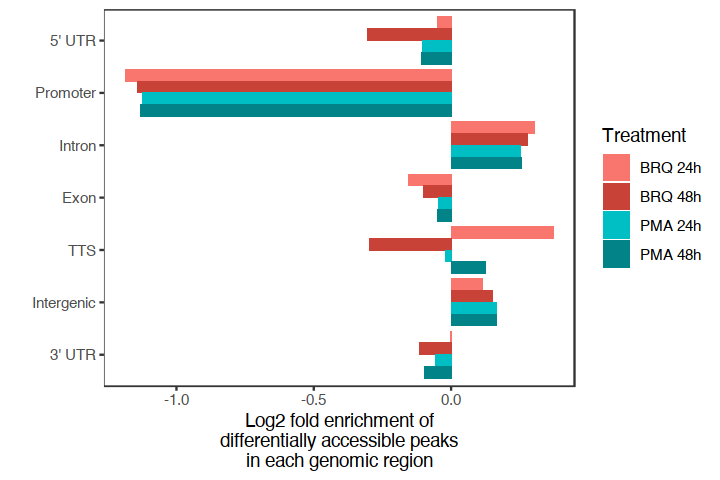

In [192]:
# Calculating log2 fold change for each region/sample 
log2_region_changes = log2(with(baseline_freqs, cbind(brq24/Freq, brq48/Freq, pma24/Freq, pma48/Freq)))
rownames(log2_region_changes) = rownames(baseline_freqs)
colnames(log2_region_changes) = c("BRQ 24h", "BRQ 48h", "PMA 24h", "PMA 48h")
log2_region_changes_m = melt(log2_region_changes)
colnames(log2_region_changes_m) = c("Region", "Treatment", "log2fc")
log2_region_changes_m$Region = factor(log2_region_changes_m$Region, levels=
rev(c("5' UTR", "Promoter", "Intron", "Exon", "TTS", "Intergenic", "3' UTR")))
log2_region_changes_m$Treatment = factor(log2_region_changes_m$Treatment, levels=rev(c("BRQ 24h", "BRQ 48h", "PMA 24h", "PMA 48h")))

ggplot(data = log2_region_changes_m, aes(x=Region, y=log2fc, fill=Treatment)) + 
geom_col(position = "dodge") + theme_bw() + theme(panel.grid.major = element_blank(),
panel.grid.minor = element_blank()) + coord_flip() + geom_vline(xintercept=0) +
ylab("Log2 fold enrichment of\ndifferentially accessible peaks\nin each genomic region") +
xlab("") + scale_fill_manual(values = c("BRQ 24h" = "#F8766D",
                                "BRQ 48h"="#c94238",
                                "PMA 24h"="#00BFC4",
                                "PMA 48h"="#018388")) 

#ggsave("../output/220510_thp1_atac_dapeaks_enrichment.pdf", width=4, height=4)

## Concordance between peak accessibility and gene expression

In [18]:
# make a list of peaks with >25% ATAC signal at some point during treatment, and >25% K4me1 signal for GREAT
tatac = as.numeric(quantile(df_norm_comb$dmso, 0.25))
tk27ac = as.numeric(quantile(df_norm_comb$d_k27ac, 0.25))

df_norm_comb_hi = subset(df_norm_comb, (apply(df_norm_comb[,1:5], 1, max) > tatac) &
                                       (apply(df_norm_comb[,6:10], 1, max) > tk27ac))
dim(df_norm_comb_hi)

[1] 169811     27

In [19]:
# make bed file for GREAT
df_norm_comb_hi_bed = peak_info[rownames(df_norm_comb_hi),]
df_norm_comb_hi_bed = cbind(df_norm_comb_hi_bed[,1:3], rownames(df_norm_comb_hi_bed), df_norm_comb_hi_bed$Length, df_norm_comb_hi_bed$Strand)
head(df_norm_comb_hi_bed)
#write.table(df_norm_comb_hi_bed, file = "../output/220226_thp1_atac_k27achi.bed", quote = F, col.names=F, row.names=F)

,Chr,Start,End,rownames(df_norm_comb_hi_bed),df_norm_comb_hi_bed$Length,df_norm_comb_hi_bed$Strand
,<chr>,<int>,<int>,<chr>,<int>,<chr>
peak1,chr1,807052,807600,peak1,549,+
peak2,chr1,807670,808321,peak2,652,+
peak3,chr1,810868,811240,peak3,373,+
peak4,chr1,817208,817986,peak4,779,+
peak5,chr1,826704,827907,peak5,1204,+
peak6,chr1,838302,838622,peak6,321,+


In [20]:
# processing region-gene associations from GREAT
great_data = read.table("../data/20220226-public-4.0.4-WIViwg-hg38-all-region.txt", sep='\t')
great_data = great_data[great_data$V2 != "NONE",]
great_data$gene = sapply(great_data$V2, function(x) strsplit(x, split = ' ')[[1]][1])
great_data$dist = sapply(great_data$V2, function(x) strsplit(x, split = ' ')[[1]][2])
great_data$dist = as.numeric(gsub('(', '', gsub(')', '', great_data$dist, fixed=T), fixed=T))
rownames(great_data) = great_data$V1
colnames(great_data) = c("peak_id", "great_output", "gene", "dist")
head(great_data)

,peak_id,great_output,gene,dist
,<chr>,<chr>,<chr>,<dbl>
peak10,peak10,SAMD11 (-48887),SAMD11,-48887
peak11,peak11,SAMD11 (-34756),SAMD11,-34756
peak12,peak12,SAMD11 (-21736),SAMD11,-21736
peak13,peak13,SAMD11 (-21146),SAMD11,-21146
peak14,peak14,SAMD11 (-14389),SAMD11,-14389
peak15,peak15,SAMD11 (-12725),SAMD11,-12725


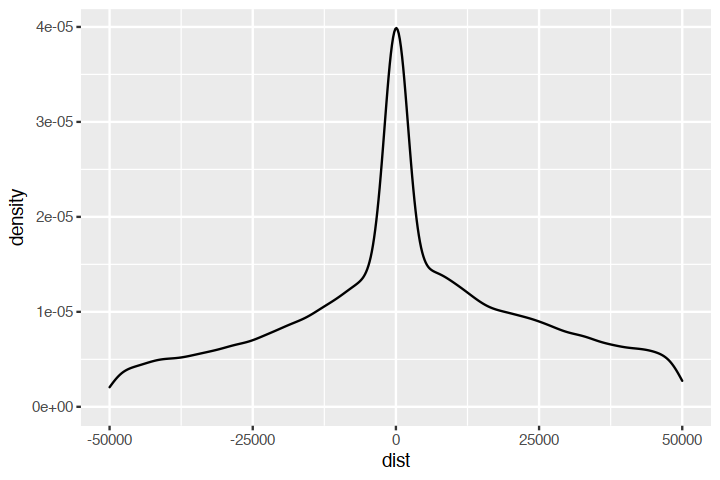

In [21]:
# distance of peaks from TSS
options(repr.plot.height=4, repr.plot.width=6)
ggplot(great_data, aes(x=dist)) + geom_density()

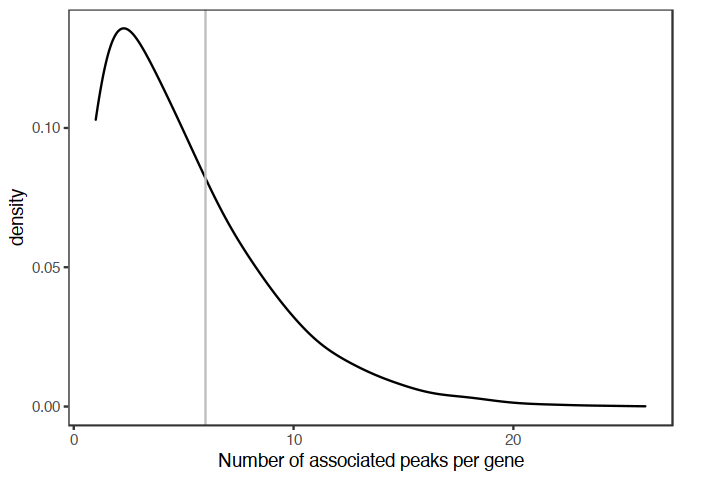

In [22]:
# number of regions per gene
counts = great_data %>% count(gene)
rownames(counts) = counts$gene
ggplot(counts, aes(x=n)) + geom_density(adjust=2) +
geom_vline(xintercept=6, color="gray") + xlab("Number of associated peaks per gene") +
           theme_bw() + theme(panel.grid.major = element_blank(), 
                              panel.grid.minor = element_blank(),
                              plot.margin = unit(c(0.2,1,0.2,0.2), "cm"))
#ggsave("../output/220226_thp1_num_peaks.pdf", width=3, height=2.5) 

In [23]:
# high complexity genes -- top tertile
z = as.numeric(quantile(counts$n, 0.666))
print(z)
counts_high = subset(counts, n >= z)
dim(counts_high)

[1] 6


[1] 6191    2

### Associated peaks

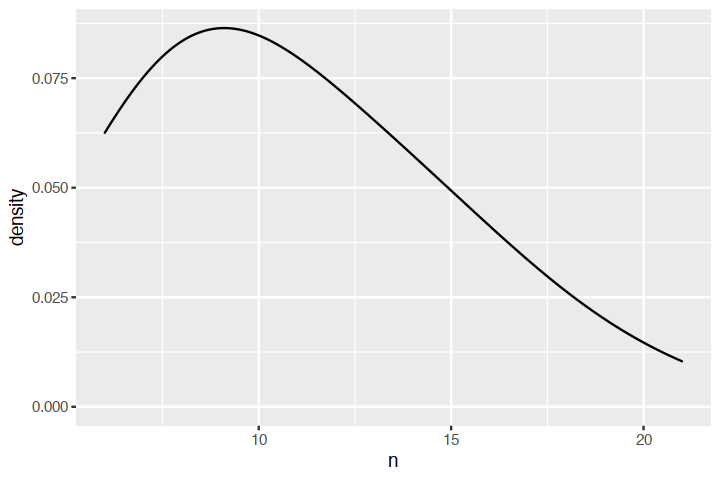

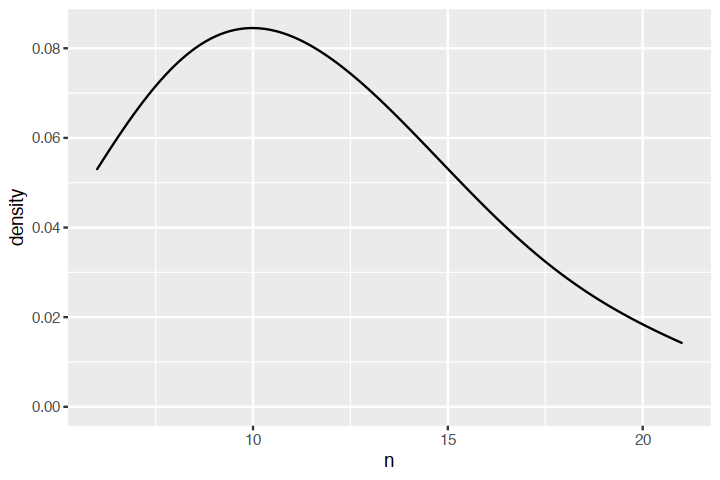

In [33]:
# top 100 BRQ and PMA genes, and associated numbers of peaks 
z = rownames(rnaseq_lfc_hicomplexity[order(-rnaseq_lfc_hicomplexity$b48_rna_lfc), ][1:100,])
ggplot(counts[z,], aes(x=n)) + geom_density(adjust=2)
z = rownames(rnaseq_lfc_hicomplexity[order(-rnaseq_lfc_hicomplexity$p48_rna_lfc), ][1:100,])
ggplot(counts[z,], aes(x=n)) + geom_density(adjust=2)


[1] 61099

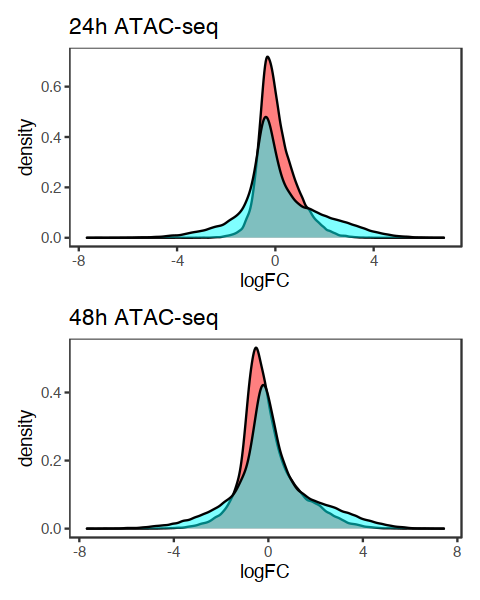

In [34]:
# z is the set of peaks that is ATAC > 25th percentile, K4me1 > 25th percentile, and within 50kb of genes
z = intersect(rownames(b24_dep), rownames(great_data))
length(z)

g1 = ggplot() + geom_density(data = b24_dep[z,], aes(x=logFC), fill="red", alpha=0.5) +
           geom_density(data = p24_dep[z,], aes(x=logFC), fill="cyan", alpha=0.5) + ggtitle("24h ATAC-seq") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())

g2 = ggplot() + geom_density(data = b48_dep[z,], aes(x=logFC), fill="red", alpha=0.5) +
           geom_density(data = p48_dep[z,], aes(x=logFC), fill="cyan", alpha=0.5) + ggtitle("48h ATAC-seq") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())

options(repr.plot.width=4, repr.plot.height=5)
g1 / g2
#ggsave("../output/220226_thp1_peaks_density.pdf", width=4, height=5)

In [35]:
shared_up = subset(rnaseq_lfc_hicomplexity, (b48_rna_lfc > 1) & (p48_rna_lfc > 1))
ATAC_LFC_THRESH = 0.5
dim(shared_up)
#head(shared_up)

# peaks that are in both the GREAT data and the differential analysis
z = intersect(rownames(b48_dep), rownames(great_data))

# fraction of peaks that become more accessible in B48
b48_dep_great = cbind(b48_dep[z, ], great_data[z, ])
b48_great_upreg = b48_dep_great[which(b48_dep_great$gene %in% rownames(shared_up)), ]
b48_frac_up = b48_great_upreg %>% group_by(gene) %>% 
        summarize(Frac = sum((logFC > ATAC_LFC_THRESH) & (adj.P.Val < 0.05))/
                        sum((adj.P.Val <= 1)))
b48_frac_up$lfc = shared_up[b48_frac_up$gene, ]$b48_rna_lfc

# fraction of peaks that become more accessible in P48
p48_dep_great = cbind(p48_dep[z, ], great_data[z, ])
p48_great_upreg = p48_dep_great[which(b48_dep_great$gene %in% rownames(shared_up)), ]
p48_frac_up = p48_great_upreg %>% group_by(gene) %>% 
        summarize(Frac = sum((logFC > ATAC_LFC_THRESH) & (adj.P.Val < 0.05))/
                        sum((adj.P.Val <= 1)))
p48_frac_up$lfc = shared_up[p48_frac_up$gene, ]$p48_rna_lfc

# merging data frame
frac_48h = merge(b48_frac_up, p48_frac_up, by="gene")
rownames(frac_48h) = frac_48h$gene
colnames(frac_48h) = c("gene", "b48_frac", "b48_lfc", "p48_frac", "p48_lfc")

[1] 517   4

In [243]:
b48_great_upreg$activity_dist = b48_great_upreg$logFC/abs(b48_great_upreg$dist)
b48_activity_dist = b48_great_upreg %>% group_by(gene) %>% 
        summarize(abc = sum(activity_dist))

p48_great_upreg$activity_dist = p48_great_upreg$logFC/abs(p48_great_upreg$dist)
p48_activity_dist = p48_great_upreg %>% group_by(gene) %>% 
        summarize(abc = sum(activity_dist))

b48_med = b48_great_upreg %>% group_by(gene) %>% 
        summarize(med = median(logFC))

p48_med = p48_great_upreg %>% group_by(gene) %>% 
        summarize(med = median(logFC))

frac_48h = merge(frac_48h, b48_activity_dist, by="gene")
frac_48h = merge(frac_48h, p48_activity_dist, by="gene")
frac_48h = merge(frac_48h, b48_med, by="gene")
frac_48h = merge(frac_48h, p48_med, by="gene")

rownames(frac_48h) = frac_48h$gene
colnames(frac_48h) = c("gene", "b48_frac", "b48_lfc", "p48_frac", "p48_lfc", "b48_abc", "p48_abc", "b48_med", "p48_med")
head(frac_48h)

,gene,b48_frac,b48_lfc,p48_frac,p48_lfc,b48_abc,p48_abc,b48_med,p48_med
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M,A2M,0.5000000,2.975828,0.5000000,7.551028,2.311839e-02,0.0604854370,0.3062836,1.4627755
ABCB4,ABCB4,0.0000000,1.233417,0.0000000,4.399901,-1.064287e-03,0.0001313900,-0.4790595,-1.1721528
ABHD17C,ABHD17C,0.3000000,1.506301,0.7000000,2.495164,1.348569e-05,0.0028010300,0.1234407,1.8144577
ABHD2,ABHD2,0.4285714,1.496904,0.7142857,3.246243,-4.205939e-02,0.0402153228,1.0179019,1.7946717
ABHD4,ABHD4,0.2857143,2.754172,0.7142857,6.196616,7.429146e-04,0.0038613837,0.1094745,1.0939856
ABTB2,ABTB2,0.3000000,1.569444,0.2000000,3.667977,-5.709014e-04,-0.0005786846,-0.1398246,-0.8267991


In [244]:
wilcox.test(frac_48h$b48_abc, frac_48h$p48_abc)
wilcox.test(frac_48h$b48_med, frac_48h$p48_med)


	Wilcoxon rank sum test with continuity correction

data:  frac_48h$b48_abc and frac_48h$p48_abc
W = 80621, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum test with continuity correction

data:  frac_48h$b48_med and frac_48h$p48_med
W = 94786, p-value = 5.821e-16
alternative hypothesis: true location shift is not equal to 0


Warning message:
“Removed 34 rows containing non-finite values (stat_density).”
Warning message:
“Removed 47 rows containing non-finite values (stat_density).”
Warning message:
“Removed 34 rows containing non-finite values (stat_density).”
Warning message:
“Removed 47 rows containing non-finite values (stat_density).”


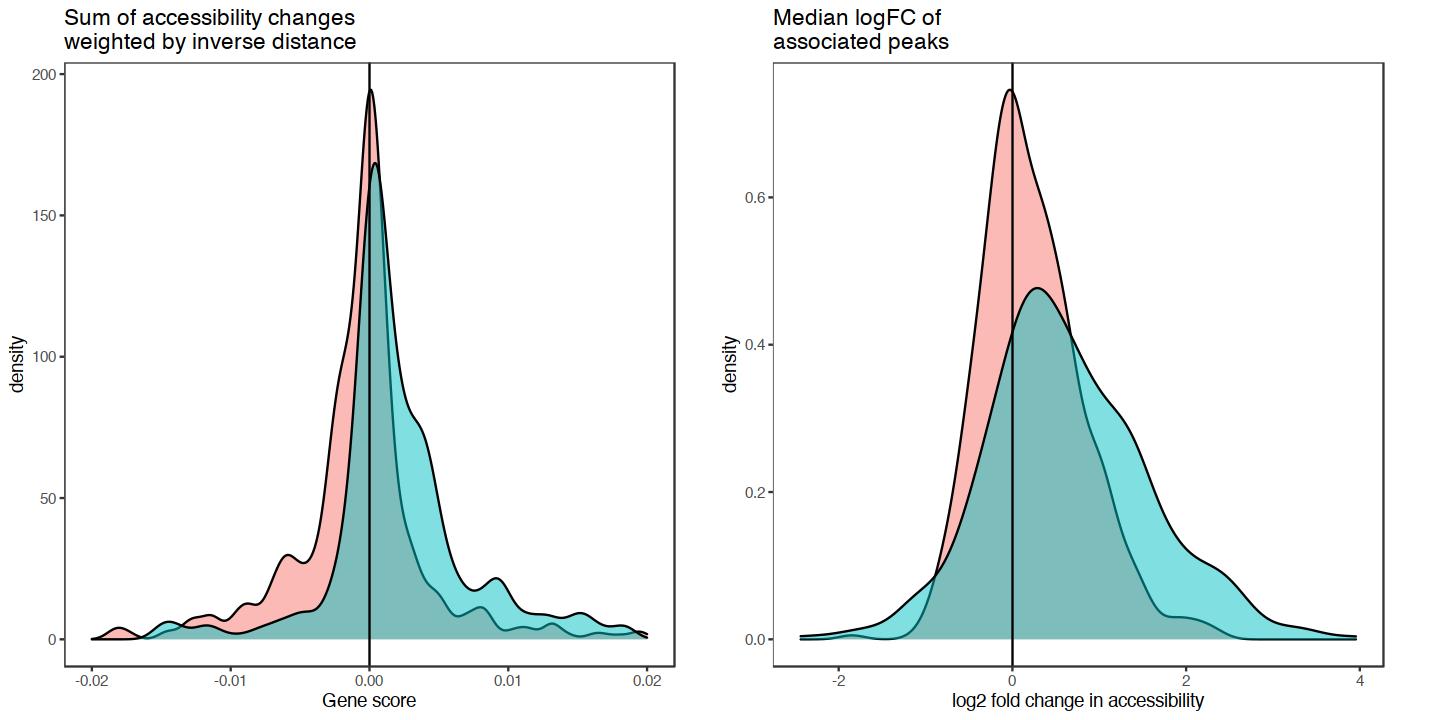

In [180]:
g1 = ggplot() + geom_density(data=frac_48h, aes(x=b48_abc), fill="#F8766D", alpha=0.5) +
           geom_density(data=frac_48h, aes(x=p48_abc), fill="#00BFC4", alpha=0.5) +
           ggtitle("Sum of accessibility changes\nweighted by inverse distance") + xlab("Gene score") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank(),
                              plot.margin = unit(c(0,1,0,0), "cm")) + xlim(-0.02, 0.02) + geom_vline(xintercept=0)

g2 = ggplot() + geom_density(data=frac_48h, aes(x=b48_med), fill="#F8766D", alpha=0.5) +
           geom_density(data=frac_48h, aes(x=p48_med), fill="#00BFC4", alpha=0.5) +
           ggtitle("Median logFC of\nassociated peaks") + xlab("log2 fold change in accessibility") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank(),
                              plot.margin = unit(c(0,1,0,0), "cm")) + geom_vline(xintercept=0)
options(repr.plot.width=12, repr.plot.height=6)
g1 + g2
ggsave("../output/220226_thp1_shared_genes_otherscores.pdf", width=6, height=2.5)


	Wilcoxon rank sum test with continuity correction

data:  b48_frac and p48_frac
W = 86313, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


[1] 0.3333333

[1] 0.5


	Wilcoxon rank sum test with continuity correction

data:  b48_lfc and p48_lfc
W = 104864, p-value = 2.047e-09
alternative hypothesis: true location shift is not equal to 0


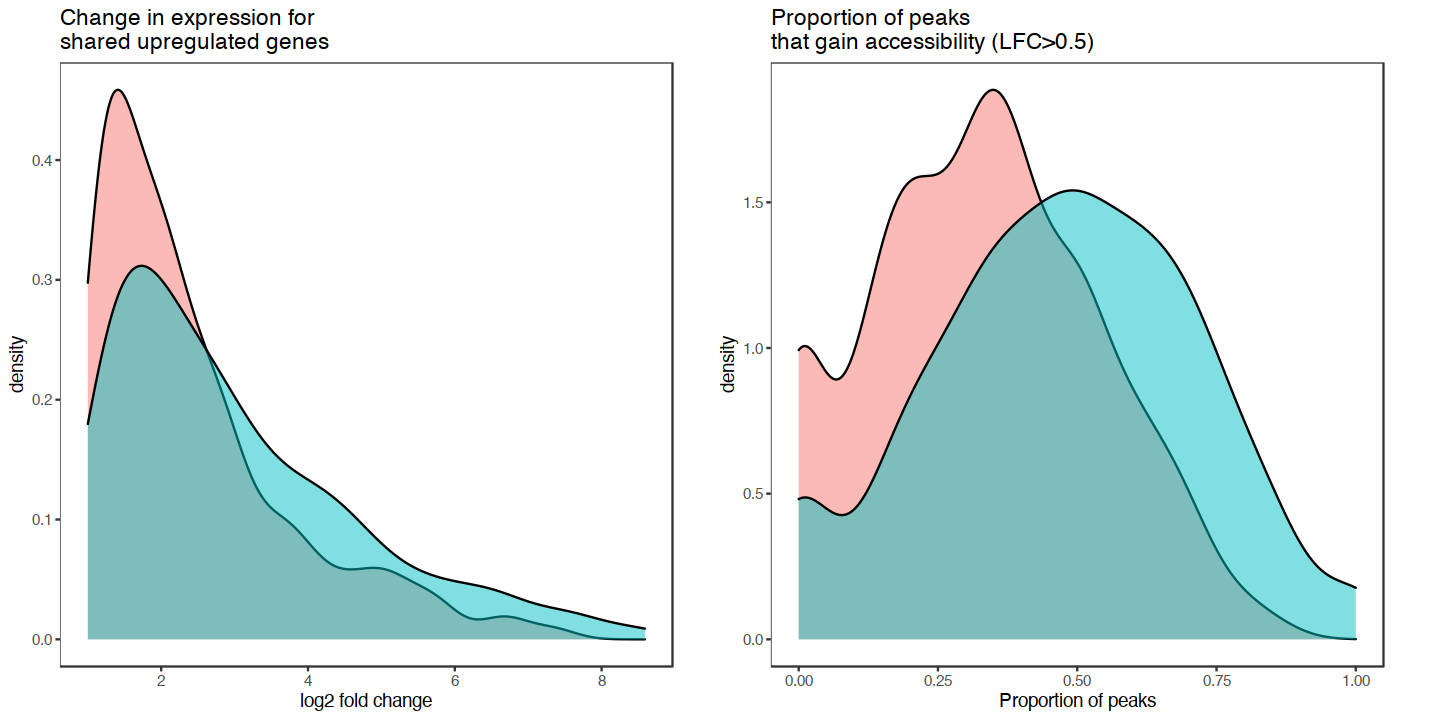

In [181]:
# plotting densities
g1 = ggplot() + geom_density(data=frac_48h, aes(x=b48_frac), fill="#F8766D", alpha=0.5) +
           geom_density(data=frac_48h, aes(x=p48_frac), fill="#00BFC4", alpha=0.5) +
           ggtitle("Proportion of peaks\nthat gain accessibility (LFC>0.5)") + xlab("Proportion of peaks") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank(),
                              plot.margin = unit(c(0,1,0,0), "cm"))

g2 = ggplot() + geom_density(data=frac_48h, aes(x=b48_lfc), fill="#F8766D", alpha=0.5) +
           geom_density(data=frac_48h, aes(x=p48_lfc), fill="#00BFC4", alpha=0.5) +
           ggtitle("Change in expression for\nshared upregulated genes") + xlab("log2 fold change") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank(),
                              plot.margin = unit(c(0,1,0,0), "cm"))

options(repr.plot.width=12, repr.plot.height=6)
g2 + g1
ggsave("../output/220226_thp1_shared_up_genes_lfc05.pdf", width=6, height=2.5)
# wilcox test 
with(frac_48h, wilcox.test(b48_frac, p48_frac))
median(frac_48h$b48_frac)
median(frac_48h$p48_frac)
with(frac_48h, wilcox.test(b48_lfc, p48_lfc))

Warning message:
“ggrepel: 463 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 477 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


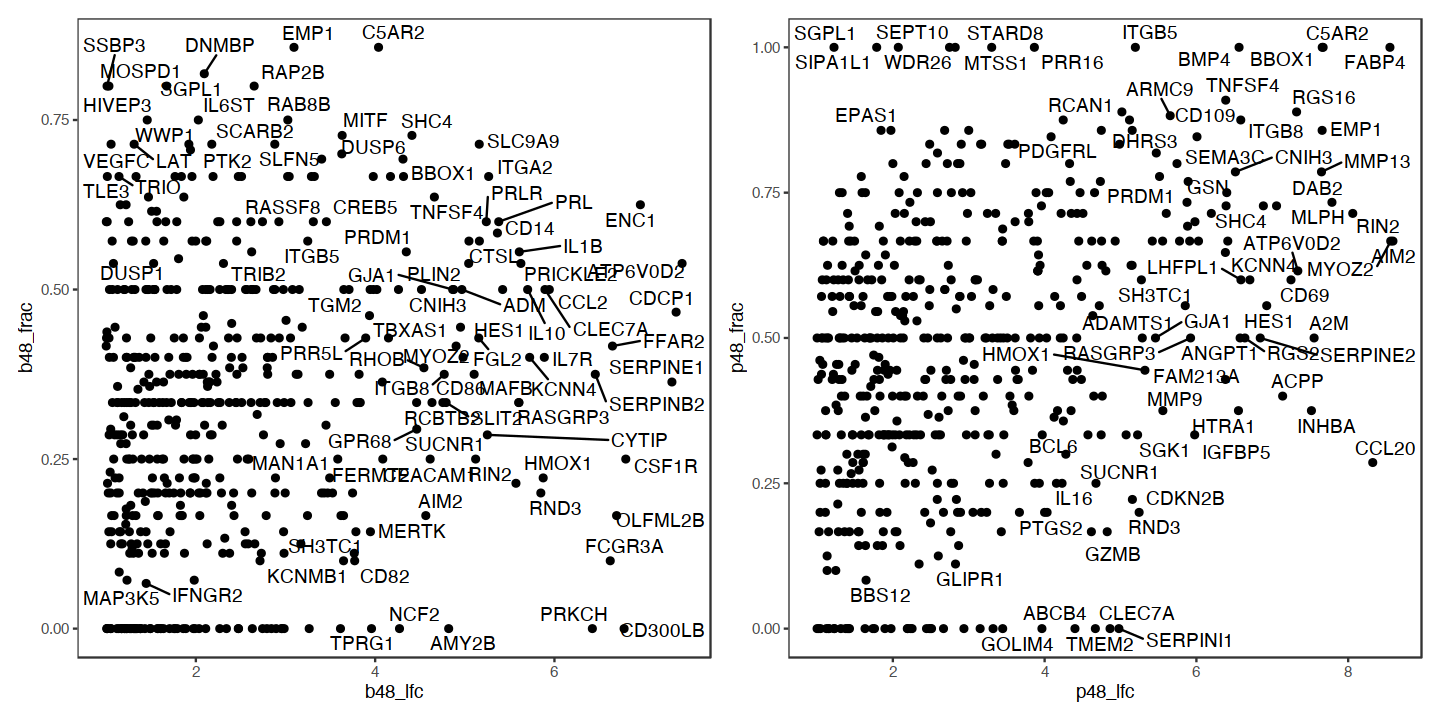

In [245]:
# Plot genes by their LFC vs proportion of accessible peaks
frac_48h$labels = ""
interesting_genes = c("MMP14", "MEF2C", "MERTK", "ZFP36L1", "AIM2", "CD300LB", "CD14", "C5AR1", "FABP4", "FCGR3A", "CSF1R", "HMOX1")
frac_48h[which(rownames(frac_48h) %in% interesting_genes), ]$labels = rownames(frac_48h[which(rownames(frac_48h) %in% interesting_genes), ])

g1 = ggplot(frac_48h, aes(x=b48_lfc, y=b48_frac, label=gene)) + geom_point() +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank()) +
            geom_text_repel(max.overlaps=10)
g2 = ggplot(frac_48h, aes(x=p48_lfc, y=p48_frac, label=gene)) + geom_point() +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank()) +
            geom_text_repel(max.overlaps=10)

options(repr.plot.width=12, repr.plot.height=6)
(g1 + g2)

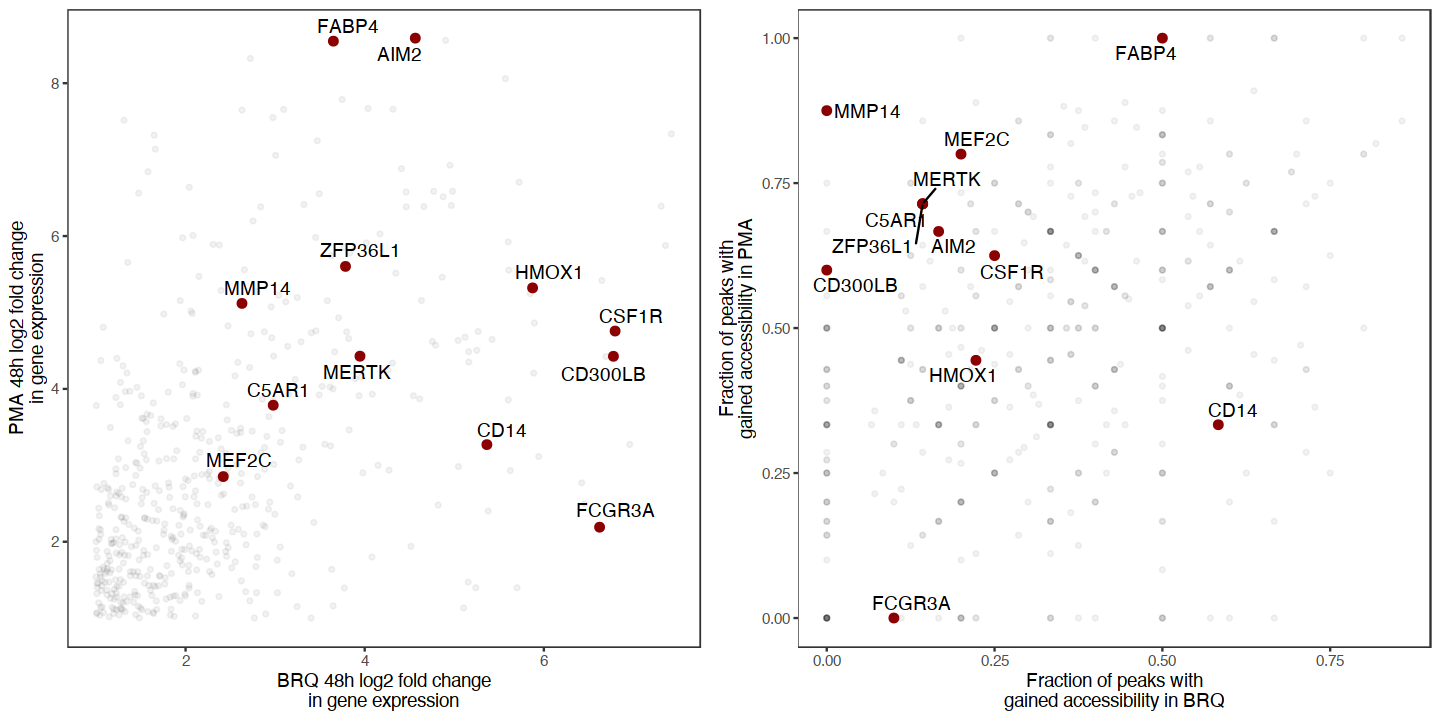

In [184]:
# Plot genes by BRQ vs PMA for each metric
g3 = ggplot(frac_48h, aes(x=b48_lfc, y=p48_lfc)) + geom_point(alpha=0.05, size=1) +
        geom_point(data=subset(frac_48h, labels != ""), color="darkred", size=2) +
        theme_bw() + theme(panel.grid.major = element_blank(),
                           panel.grid.minor = element_blank(),
                           plot.margin = unit(c(0,0.4,0,0), "cm")) +
        geom_text_repel(data=subset(frac_48h, labels != ""), aes(label=labels), 
        max.overlaps=200, force=10) + xlab("BRQ 48h log2 fold change\nin gene expression") +
        ylab("PMA 48h log2 fold change\nin gene expression")
g4 = ggplot(frac_48h, aes(x=b48_frac, y=p48_frac, label=labels)) + geom_point(alpha=0.05, size=1) +
        geom_point(data=subset(frac_48h, labels != ""), color="darkred", size=2) +
        theme_bw() + theme(panel.grid.major = element_blank(),
                            panel.grid.minor = element_blank(),
                           plot.margin = unit(c(0,0,0,0), "cm")) +
        geom_text_repel(data=subset(frac_48h, labels != ""), aes(label=labels),
        max.overlaps=200, force=10) + xlab("Fraction of peaks with\ngained accessibility in BRQ") +
        ylab("Fraction of peaks with\ngained accessibility in PMA")
(g3 + g4)
ggsave("../output/220226_thp1_shared_up_genes_scatter.pdf", width=6, height=3)


In [37]:
# Functions to calculate the proportion of upreg or downreg peaks for each gene
get_prop_up_peaks = function(dep, lfc, n = 100, thresh = 1) {
    z = intersect(rownames(dep), rownames(great_data))
    dep_great = cbind(dep[z, ], great_data[z, ])
    upreg = rownames(rnaseq_lfc_hicomplexity[order(-rnaseq_lfc_hicomplexity[,lfc]), ][1:n,])
    great_upreg = dep_great[which(dep_great$gene %in% upreg), ]
    frac_up = great_upreg %>% group_by(gene) %>% 
            summarize(Frac = sum((logFC > thresh) & (adj.P.Val < 0.05))/
                            sum((adj.P.Val <= 1)))
    return(frac_up)
}

get_prop_down_peaks = function(dep, lfc, n = 100, thresh = -1) {
    z = intersect(rownames(dep), rownames(great_data))
    dep_great = cbind(dep[z, ], great_data[z, ])
    downreg = rownames(rnaseq_lfc_hicomplexity[order(rnaseq_lfc_hicomplexity[,lfc]), ][1:n,])
    great_downreg = dep_great[which(dep_great$gene %in% downreg), ]
    frac_down = great_downreg  %>% group_by(gene) %>% 
            summarize(Frac = sum((logFC < thresh) & (adj.P.Val < 0.05))/
                            sum((adj.P.Val <= 1)))
    return(frac_down)
}

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



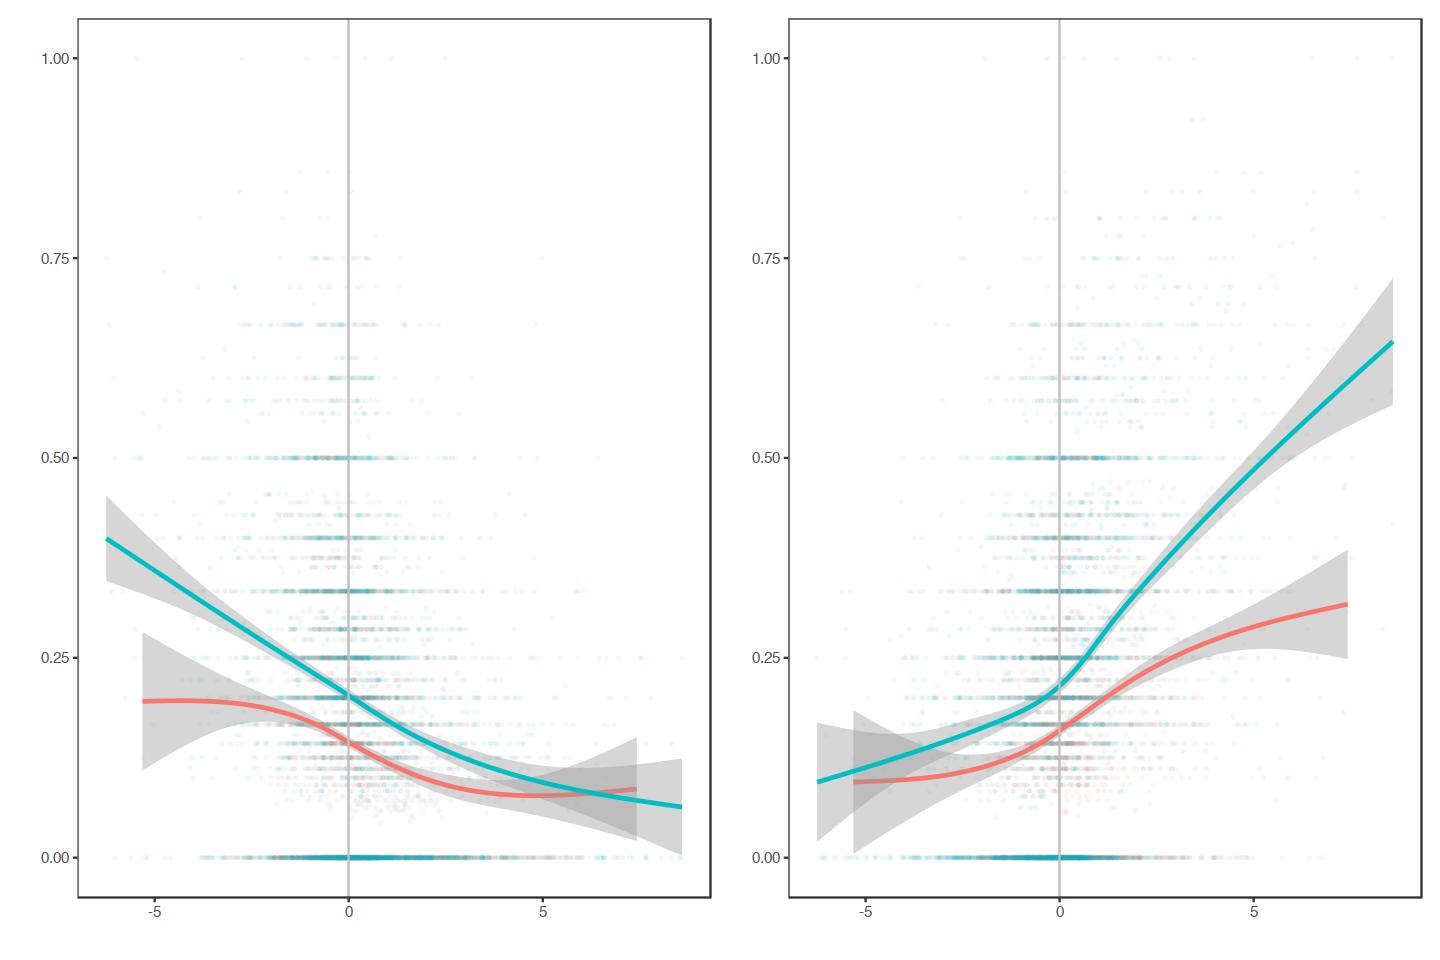

In [52]:
# Plot for all high-complexity genes (48h)
# up peaks
b48_prop_all = get_prop_up_peaks(b48_dep, "b48_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = 1)
b48_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[b48_prop_all$gene, ]$b48_rna_lfc
p48_prop_all = get_prop_up_peaks(p48_dep, "p48_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = 1)
p48_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[p48_prop_all$gene, ]$p48_rna_lfc

g1 = ggplot(b48_prop_all, aes(x=rnaseq_lfc, y=Frac)) + 
rasterize(geom_point(alpha=0.05, col="#F8766D", size=0.5), dpi=150) +
rasterize(geom_point(data=p48_prop_all, alpha=0.05, col="#00BFC4", size=0.5), dpi=150) +
geom_smooth(col="#F8766D") +
geom_smooth(data=p48_prop_all, col="#00BFC4") +
xlab("") + ylab("") + geom_vline(xintercept = 0, col="gray") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())


# g2 = ggplot(p48_prop_all, aes(x=rnaseq_lfc, y=Frac)) + rasterize(geom_point(alpha=0.05), dpi=150) + geom_smooth(col="#00BFC4") +
# xlab("log2 fold change\nin gene expression") + ylab("") + geom_vline(xintercept = 0, col="gray") +
#            theme_bw() + theme(panel.grid.major = element_blank(),
#                               panel.grid.minor = element_blank())

# down peaks
b48_prop_all = get_prop_down_peaks(b48_dep, "b48_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = -1)
b48_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[b48_prop_all$gene, ]$b48_rna_lfc
p48_prop_all = get_prop_down_peaks(p48_dep, "p48_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = -1)
p48_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[p48_prop_all$gene, ]$p48_rna_lfc

g3 = ggplot(b48_prop_all, aes(x=rnaseq_lfc, y=Frac)) + 
rasterize(geom_point(alpha=0.05, col="#F8766D", size=0.5), dpi=150) +
rasterize(geom_point(data=p48_prop_all, alpha=0.05, col="#00BFC4", size=0.5), dpi=150) +
geom_smooth(col="#F8766D") +
geom_smooth(data=p48_prop_all, col="#00BFC4") +
xlab("") + ylab("") + geom_vline(xintercept = 0, col="gray") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())


# g4 = ggplot(p48_prop_all, aes(x=rnaseq_lfc, y=Frac)) + rasterize(geom_point(alpha=0.05), dpi=150) + geom_smooth(col="#00BFC4") +
# xlab("log2 fold change\nin gene expression") + ylab("Proportion of peaks") + geom_vline(xintercept = 0, col="gray") +
#            theme_bw() + theme(panel.grid.major = element_blank(),
#                               panel.grid.minor = element_blank())

options(repr.plot.width=12, repr.plot.height=8)
g3 + g1
# (g3 + g1) / (g4 + g2)
ggsave("../output/220510_thp1_all_genes_peaks_scatter48.pdf", width=6, height=3)

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



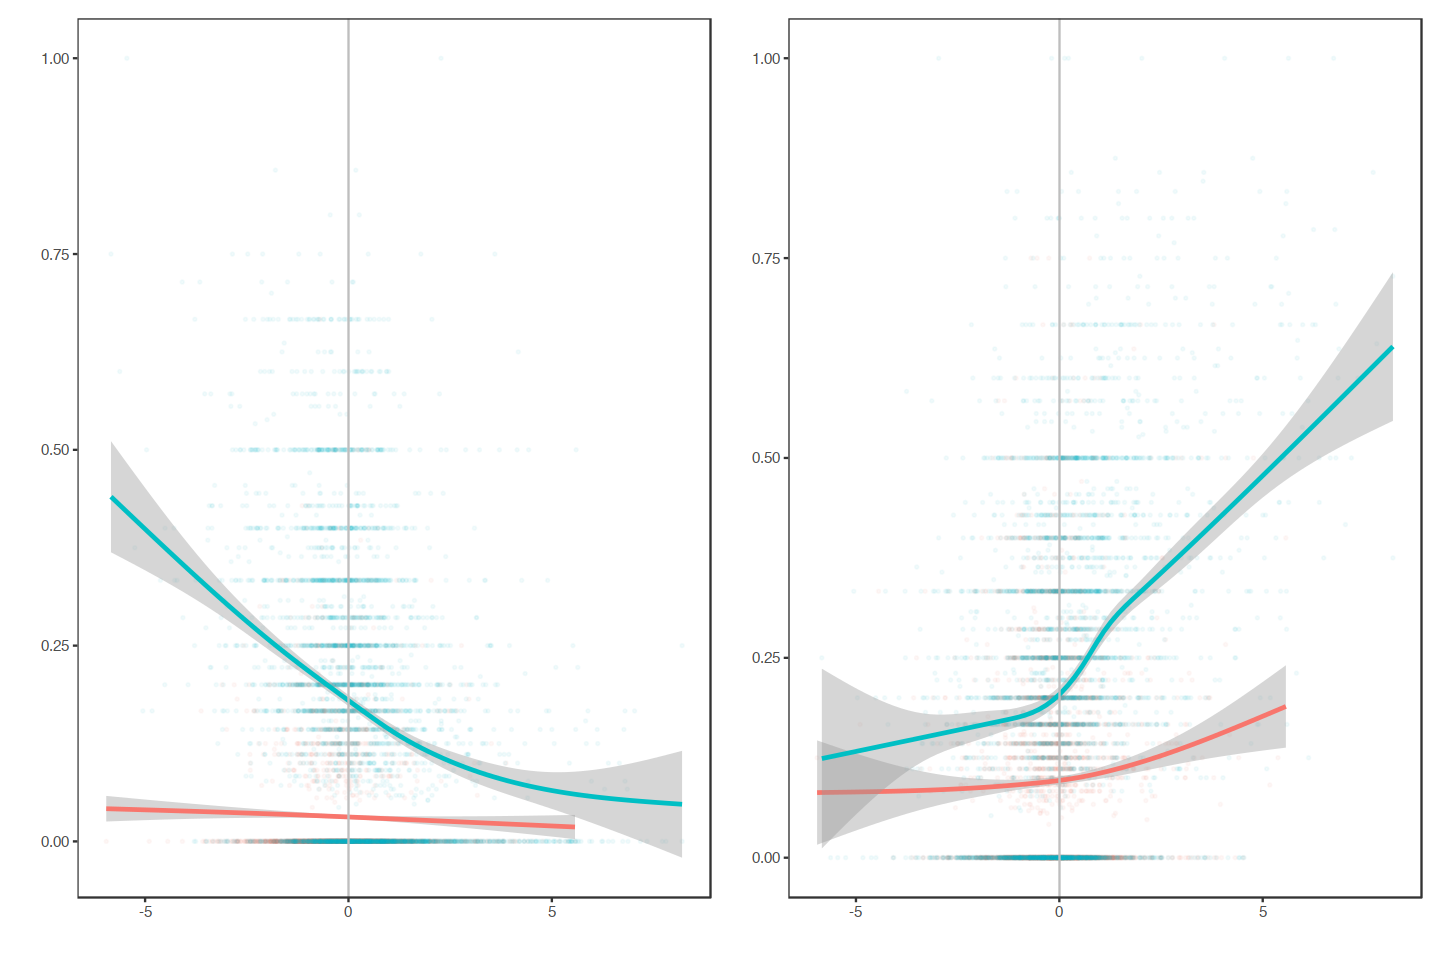

In [53]:
# Plot for all high-complexity genes (24h)
# up peaks
b24_prop_all = get_prop_up_peaks(b24_dep, "b24_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = 1)
b24_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[b24_prop_all$gene, ]$b24_rna_lfc
p24_prop_all = get_prop_up_peaks(p24_dep, "p24_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = 1)
p24_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[p24_prop_all$gene, ]$p24_rna_lfc

g1 = ggplot(b24_prop_all, aes(x=rnaseq_lfc, y=Frac)) + 
rasterize(geom_point(alpha=0.05, col="#F8766D", size=0.5), dpi=150) +
rasterize(geom_point(data=p24_prop_all, alpha=0.05, col="#00BFC4", size=0.5), dpi=150) +
geom_smooth(col="#F8766D") +
geom_smooth(data=p24_prop_all, col="#00BFC4") +
xlab("") + ylab("") + geom_vline(xintercept = 0, col="gray") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())


# g2 = ggplot(p24_prop_all, aes(x=rnaseq_lfc, y=Frac)) + rasterize(geom_point(alpha=0.05), dpi=150) + geom_smooth(col="#00BFC4") +
# xlab("log2 fold change\nin gene expression") + ylab("") + geom_vline(xintercept = 0, col="gray") +
#            theme_bw() + theme(panel.grid.major = element_blank(),
#                               panel.grid.minor = element_blank())

# down peaks
b24_prop_all = get_prop_down_peaks(b24_dep, "b24_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = -1)
b24_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[b24_prop_all$gene, ]$b24_rna_lfc
p24_prop_all = get_prop_down_peaks(p24_dep, "p24_rna_lfc", n = dim(rnaseq_lfc_hicomplexity)[1], thresh = -1)
p24_prop_all$rnaseq_lfc = rnaseq_lfc_hicomplexity[p24_prop_all$gene, ]$p24_rna_lfc

g3 = ggplot(b24_prop_all, aes(x=rnaseq_lfc, y=Frac)) + 
rasterize(geom_point(alpha=0.05, col="#F8766D", size=0.5), dpi=150) +
rasterize(geom_point(data=p24_prop_all, alpha=0.05, col="#00BFC4", size=0.5), dpi=150) +
geom_smooth(col="#F8766D") +
geom_smooth(data=p24_prop_all, col="#00BFC4") +
xlab("") + ylab("") + geom_vline(xintercept = 0, col="gray") +
           theme_bw() + theme(panel.grid.major = element_blank(),
                              panel.grid.minor = element_blank())


# g4 = ggplot(p24_prop_all, aes(x=rnaseq_lfc, y=Frac)) + rasterize(geom_point(alpha=0.05), dpi=150) + geom_smooth(col="#00BFC4") +
# xlab("log2 fold change\nin gene expression") + ylab("Proportion of peaks") + geom_vline(xintercept = 0, col="gray") +
#            theme_bw() + theme(panel.grid.major = element_blank(),
#                               panel.grid.minor = element_blank())

options(repr.plot.width=12, repr.plot.height=8)
g3 + g1
# (g3 + g1) / (g4 + g2)
ggsave("../output/220510_thp1_all_genes_peaks_scatter24.pdf", width=6, height=3)

In [1]:
## ChromVAR

In [ ]:
## ChromVAR
library(chromVAR)
library(motifmatchr)
library(chromVARmotifs)
library(Matrix)
library(SummarizedExperiment)
library(BiocParallel)
library(BSgenome.Hsapiens.UCSC.hg38)
register(MulticoreParam(4, progressbar = TRUE))
set.seed(2017)
# use normalized peak counts -- 

peaks = makeGRangesFromDataFrame(peak_info[rownames(norm_expr),1:4])
count_matrix = as.matrix(df[rownames(norm_expr),])

# fragment_counts_brq = SummarizedExperiment(assays = list(counts = count_matrix_brq),
#                                        rowRanges = peaks)
# fragment_counts_e2w = SummarizedExperiment(assays = list(counts = count_matrix_e2w),
#                                                          rowRanges = peaks)
fragment_counts = SummarizedExperiment(assays = list(counts = count_matrix),
                                                         rowRanges = peaks)
# add GC bias
fragment_counts <- addGCBias(fragment_counts, genome = BSgenome.Hsapiens.UCSC.hg38)

# get motifs
data("human_pwms_v2") # mouse collection from greenleaf lab
get_deviations = function(data, motif_set) {
  motif_ix <- matchMotifs(motif_set, data,  genome = BSgenome.Hsapiens.UCSC.hg38)
  dev <- computeDeviations(object = data, annotations = motif_ix)
  return(dev)
}

# ordered by variability
get_values = function(data, dev, column_names, num_motifs=-1, pct=FALSE) {
  dev_deviations = deviations(dev)
  dev_zsc = deviationScores(dev)
  
  variability <- computeVariability(dev)
  
  if(num_motifs == -1) num_motifs = dim(variability)[1]
  highly_variable = variability[order(-variability[,"variability"]),][1:num_motifs,]
  dev_highvar = dev_deviations[rownames(highly_variable),]
  colnames(dev_highvar)= column_names
  if(!pct) return(dev_highvar)

  #rownames(dev_highvar) = highly_variable$name
  dev_highvar_pct = t(apply(dev_highvar,1,function(x) (x - min(x))/(max(x) - min(x))))
  return(dev_highvar_pct)
}

# ordered by when the motif is maximallly open
order_by_max = function(dev) {
  dev_order = apply(dev,1,which.max)
  return(dev[order(dev_order),])
}

melt_df = function(data) {
  dev_highvar_melt = melt(data)
  colnames(dev_highvar_melt) = c("Motif", "Timepoint", "Pct")
  return(dev_highvar_melt)
}

chname = function(x) {
  x = sub("XP_", "XP", x)
  x = sub("NP_", "NP", x)
  return(x)
}

# all
dev_human = get_deviations(fragment_counts, human_pwms_v2)
dev_human_vals = get_values(fragment_counts, dev_human, colnames(df), pct=FALSE)
dev_human_pct = get_values(fragment_counts, dev_human, colnames(df), pct=TRUE)
rownames(dev_human_pct) = sapply(rownames(dev_human_pct), 
                                     function(x) {strsplit(chname(x), '_')[[1]][3]})
rownames(dev_human_vals) = sapply(rownames(dev_human_vals), 
                                      function(x) {strsplit(chname(x), '_')[[1]][3]})
dev_human_pct = dev_human_pct[!duplicated(rownames(dev_human_pct)),]
dev_human_vals = dev_human_vals[!duplicated(rownames(dev_human_vals)),]

write.table(dev_human_vals, "../output/210629_thp1_chromvar.csv", sep=',', quote=FALSE)
